# WFCommons Montage step-by-step debug

This notebook walks through:
1) load Montage instances
2) build inputs + true graph
3) generate synthetic traces (frontier-softmax)
4) trace diagnostics
5) run MCMC + compute cover/closure metrics


In [1]:
# ───────────────────────────────────────────────────────────────
#  Bootstrap: add project root AND ensure src/ is a package
# ───────────────────────────────────────────────────────────────
import os
import sys
import pkgutil
from pathlib import Path
import runpy

current_dir = Path.cwd()
project_root = current_dir.parents[0]
src_dir = project_root / "src"
utils_dir = src_dir / "utils"

for d in (src_dir, utils_dir):
    d.mkdir(parents=True, exist_ok=True)
    init_file = d / "__init__.py"
    if not init_file.exists():
        init_file.touch()

project_root_str = str(project_root)
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

print("Project root:", project_root_str)
print("src package found?", pkgutil.find_loader("src") is not None)

import json
import math
import random
from typing import Dict, List

import numpy as np
import matplotlib
if "ipykernel" in sys.modules:
    try:
        import matplotlib_inline
        matplotlib.use("module://matplotlib_inline.backend_inline")
    except Exception:
        pass
else:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

Project root: /Users/dongqing/Desktop/hpo_inference_agent
src package found? True


In [2]:

from src.utils.wfcommons_loader import (
    iter_workflow_instances,
    build_hpo_inputs_from_instances,
    build_adjacency_matrix,
)
from src.utils.po_fun import BasicUtils
from src.utils.hpo_model_evaluation import (
    precision_recall,
    f1_score,
    structural_hamming_distance,
)
from src.mcmc.hpo_po_hm_mcmc_k_optim import mcmc_simulation_hpo_k_optim

helpers = runpy.run_path(str(project_root / 'notebooks/wfcommons_montage_recovery.py'))
group_instances = helpers['group_instances']
_augment_with_synthetic_traces = helpers['_augment_with_synthetic_traces']
_canonical_order_from_adj = helpers['_canonical_order_from_adj']
_summarize_trace_distribution = helpers['_summarize_trace_distribution']
_shuffle_input_indices = helpers['_shuffle_input_indices']

data_dir = project_root / 'data/wfcommons_wfinstances/montage'
group_name = 'montage-chameleon-2mass-005d'
prefer_execution_order = True
seed = 42


In [3]:
instances = list(iter_workflow_instances(data_dir))

def _get_task_ids(inst):
    task_ids = list(inst.get("task_ids") or [])
    if task_ids:
        return task_ids
    parents = inst.get("parents") or {}
    ids = set(parents.keys())
    for ps in parents.values():
        ids.update(ps)
    return sorted(ids)

rows = []
for i, inst in enumerate(instances):
    meta = inst.get("metadata", {})
    label = meta.get("source_path") or meta.get("instance_name") or f"instance_{i}"
    if isinstance(label, str) and "::" in label:
        label = label.split("::")[-1]
    task_ids = _get_task_ids(inst)
    rows.append((label, len(set(task_ids))))

for label, count in sorted(rows):
    print(f"{label}: tasks={count}")

print(f"total files: {len(rows)}")


/Users/dongqing/Desktop/hpo_inference_agent/data/wfcommons_wfinstances/montage/montage-chameleon-2mass-005d-001.json: tasks=58
/Users/dongqing/Desktop/hpo_inference_agent/data/wfcommons_wfinstances/montage/montage-chameleon-2mass-015d-001.json: tasks=310
/Users/dongqing/Desktop/hpo_inference_agent/data/wfcommons_wfinstances/montage/montage-chameleon-2mass-01d-001.json: tasks=103
/Users/dongqing/Desktop/hpo_inference_agent/data/wfcommons_wfinstances/montage/montage-chameleon-2mass-025d-001.json: tasks=619
/Users/dongqing/Desktop/hpo_inference_agent/data/wfcommons_wfinstances/montage/montage-chameleon-2mass-02d-001.json: tasks=619
/Users/dongqing/Desktop/hpo_inference_agent/data/wfcommons_wfinstances/montage/montage-chameleon-2mass-03d-001.json: tasks=748
/Users/dongqing/Desktop/hpo_inference_agent/data/wfcommons_wfinstances/montage/montage-chameleon-2mass-04d-001.json: tasks=1312
/Users/dongqing/Desktop/hpo_inference_agent/data/wfcommons_wfinstances/montage/montage-chameleon-2mass-05d-0

In [4]:
from pathlib import Path
from src.utils.wfcommons_loader import load_workflow_instance

path1 = Path("/Users/dongqing/Desktop/hpo_inference_agent/data/wfcommons_wfinstances/montage/montage-chameleon-dss-05d-001.json")
path2 = Path("/Users/dongqing/Desktop/hpo_inference_agent/data/wfcommons_wfinstances/montage/montage-chameleon-2mass-005d-001.json")
path3 = Path("/Users/dongqing/Desktop/hpo_inference_agent/data/wfcommons_wfinstances/montage/montage-chameleon-2mass-01d-001.json")

inst1 = load_workflow_instance(path1)
inst2 = load_workflow_instance(path2)
inst3 = load_workflow_instance(path3)

trace1 = inst1["execution_order"]
trace2 = inst2["execution_order"]
trace3 = inst3["execution_order"]

set1 = set(trace1)
set2 = set(trace2)
set3 = set(trace3)

common12 = set1 & set2
common13 = set1 & set3

print(f"trace1 length={len(trace1)} unique={len(set1)}")
print(f"trace2 length={len(trace2)} unique={len(set2)}")
print(f"trace3 length={len(trace3)} unique={len(set3)}")

print(f"1↔2 overlap={len(common12)} | union={len(set1 | set2)} | jaccard={len(common12)/len(set1|set2):.3f}")
print(f"1↔3 overlap={len(common13)} | union={len(set1 | set3)} | jaccard={len(common13)/len(set1|set3):.3f}")

only1 = sorted(set1 - set2)
only2 = sorted(set2 - set1)
only3 = sorted(set3 - set1)

print(f"only in trace1 (vs trace2): {len(only1)}")
print(f"only in trace2: {len(only2)}")
print(f"only in trace3 (vs trace1): {len(only3)}")

if len(only1) <= 20:
    print("  trace1-only nodes:", only1)
if len(only2) <= 20:
    print("  trace2-only nodes:", only2)
if len(only3) <= 20:
    print("  trace3-only nodes:", only3)

# Exact position matches (trace1 vs trace2)
pos_match = sum(1 for i, t in enumerate(trace1) if i < len(trace2) and trace2[i] == t)
print(f"trace1 vs trace2 same-position matches: {pos_match}/{min(len(trace1), len(trace2))}")

# Pairwise order agreement on common tasks (trace1 vs trace2)
if common12:
    pos1 = {t: i for i, t in enumerate(trace1) if t in common12}
    pos2 = {t: i for i, t in enumerate(trace2) if t in common12}
    common_list = list(common12)
    agree = 0
    total = 0
    for i in range(len(common_list)):
        for j in range(i + 1, len(common_list)):
            a, b = common_list[i], common_list[j]
            order1 = pos1[a] < pos1[b]
            order2 = pos2[a] < pos2[b]
            agree += int(order1 == order2)
            total += 1
    print(f"trace1 vs trace2 pairwise order agreement: {agree/total:.3f} (discordant={1-agree/total:.3f})")

    # Exact position matches (trace1 vs trace3)
pos_match_13 = sum(1 for i, t in enumerate(trace1) if i < len(trace3) and trace3[i] == t)
print(f"trace1 vs trace3 same-position matches: {pos_match_13}/{min(len(trace1), len(trace3))}")

# Pairwise order agreement on common tasks (trace1 vs trace3)
if common13:
    pos1_13 = {t: i for i, t in enumerate(trace1) if t in common13}
    pos3_13 = {t: i for i, t in enumerate(trace3) if t in common13}
    common_list_13 = list(common13)
    agree_13 = 0
    total_13 = 0
    for i in range(len(common_list_13)):
        for j in range(i + 1, len(common_list_13)):
            a, b = common_list_13[i], common_list_13[j]
            order1 = pos1_13[a] < pos1_13[b]
            order3 = pos3_13[a] < pos3_13[b]
            agree_13 += int(order1 == order3)
            total_13 += 1
    print(f"trace1 vs trace3 pairwise order agreement: {agree_13/total_13:.3f} (discordant={1-agree_13/total_13:.3f})")



trace1 length=58 unique=58
trace2 length=58 unique=58
trace3 length=103 unique=103
1↔2 overlap=58 | union=58 | jaccard=1.000
1↔3 overlap=16 | union=145 | jaccard=0.110
only in trace1 (vs trace2): 0
only in trace2: 0
only in trace3 (vs trace1): 87
  trace1-only nodes: []
  trace2-only nodes: []
trace1 vs trace2 same-position matches: 58/58
trace1 vs trace2 pairwise order agreement: 1.000 (discordant=0.000)
trace1 vs trace3 same-position matches: 16/58
trace1 vs trace3 pairwise order agreement: 1.000 (discordant=0.000)


module://matplotlib_inline.backend_inline


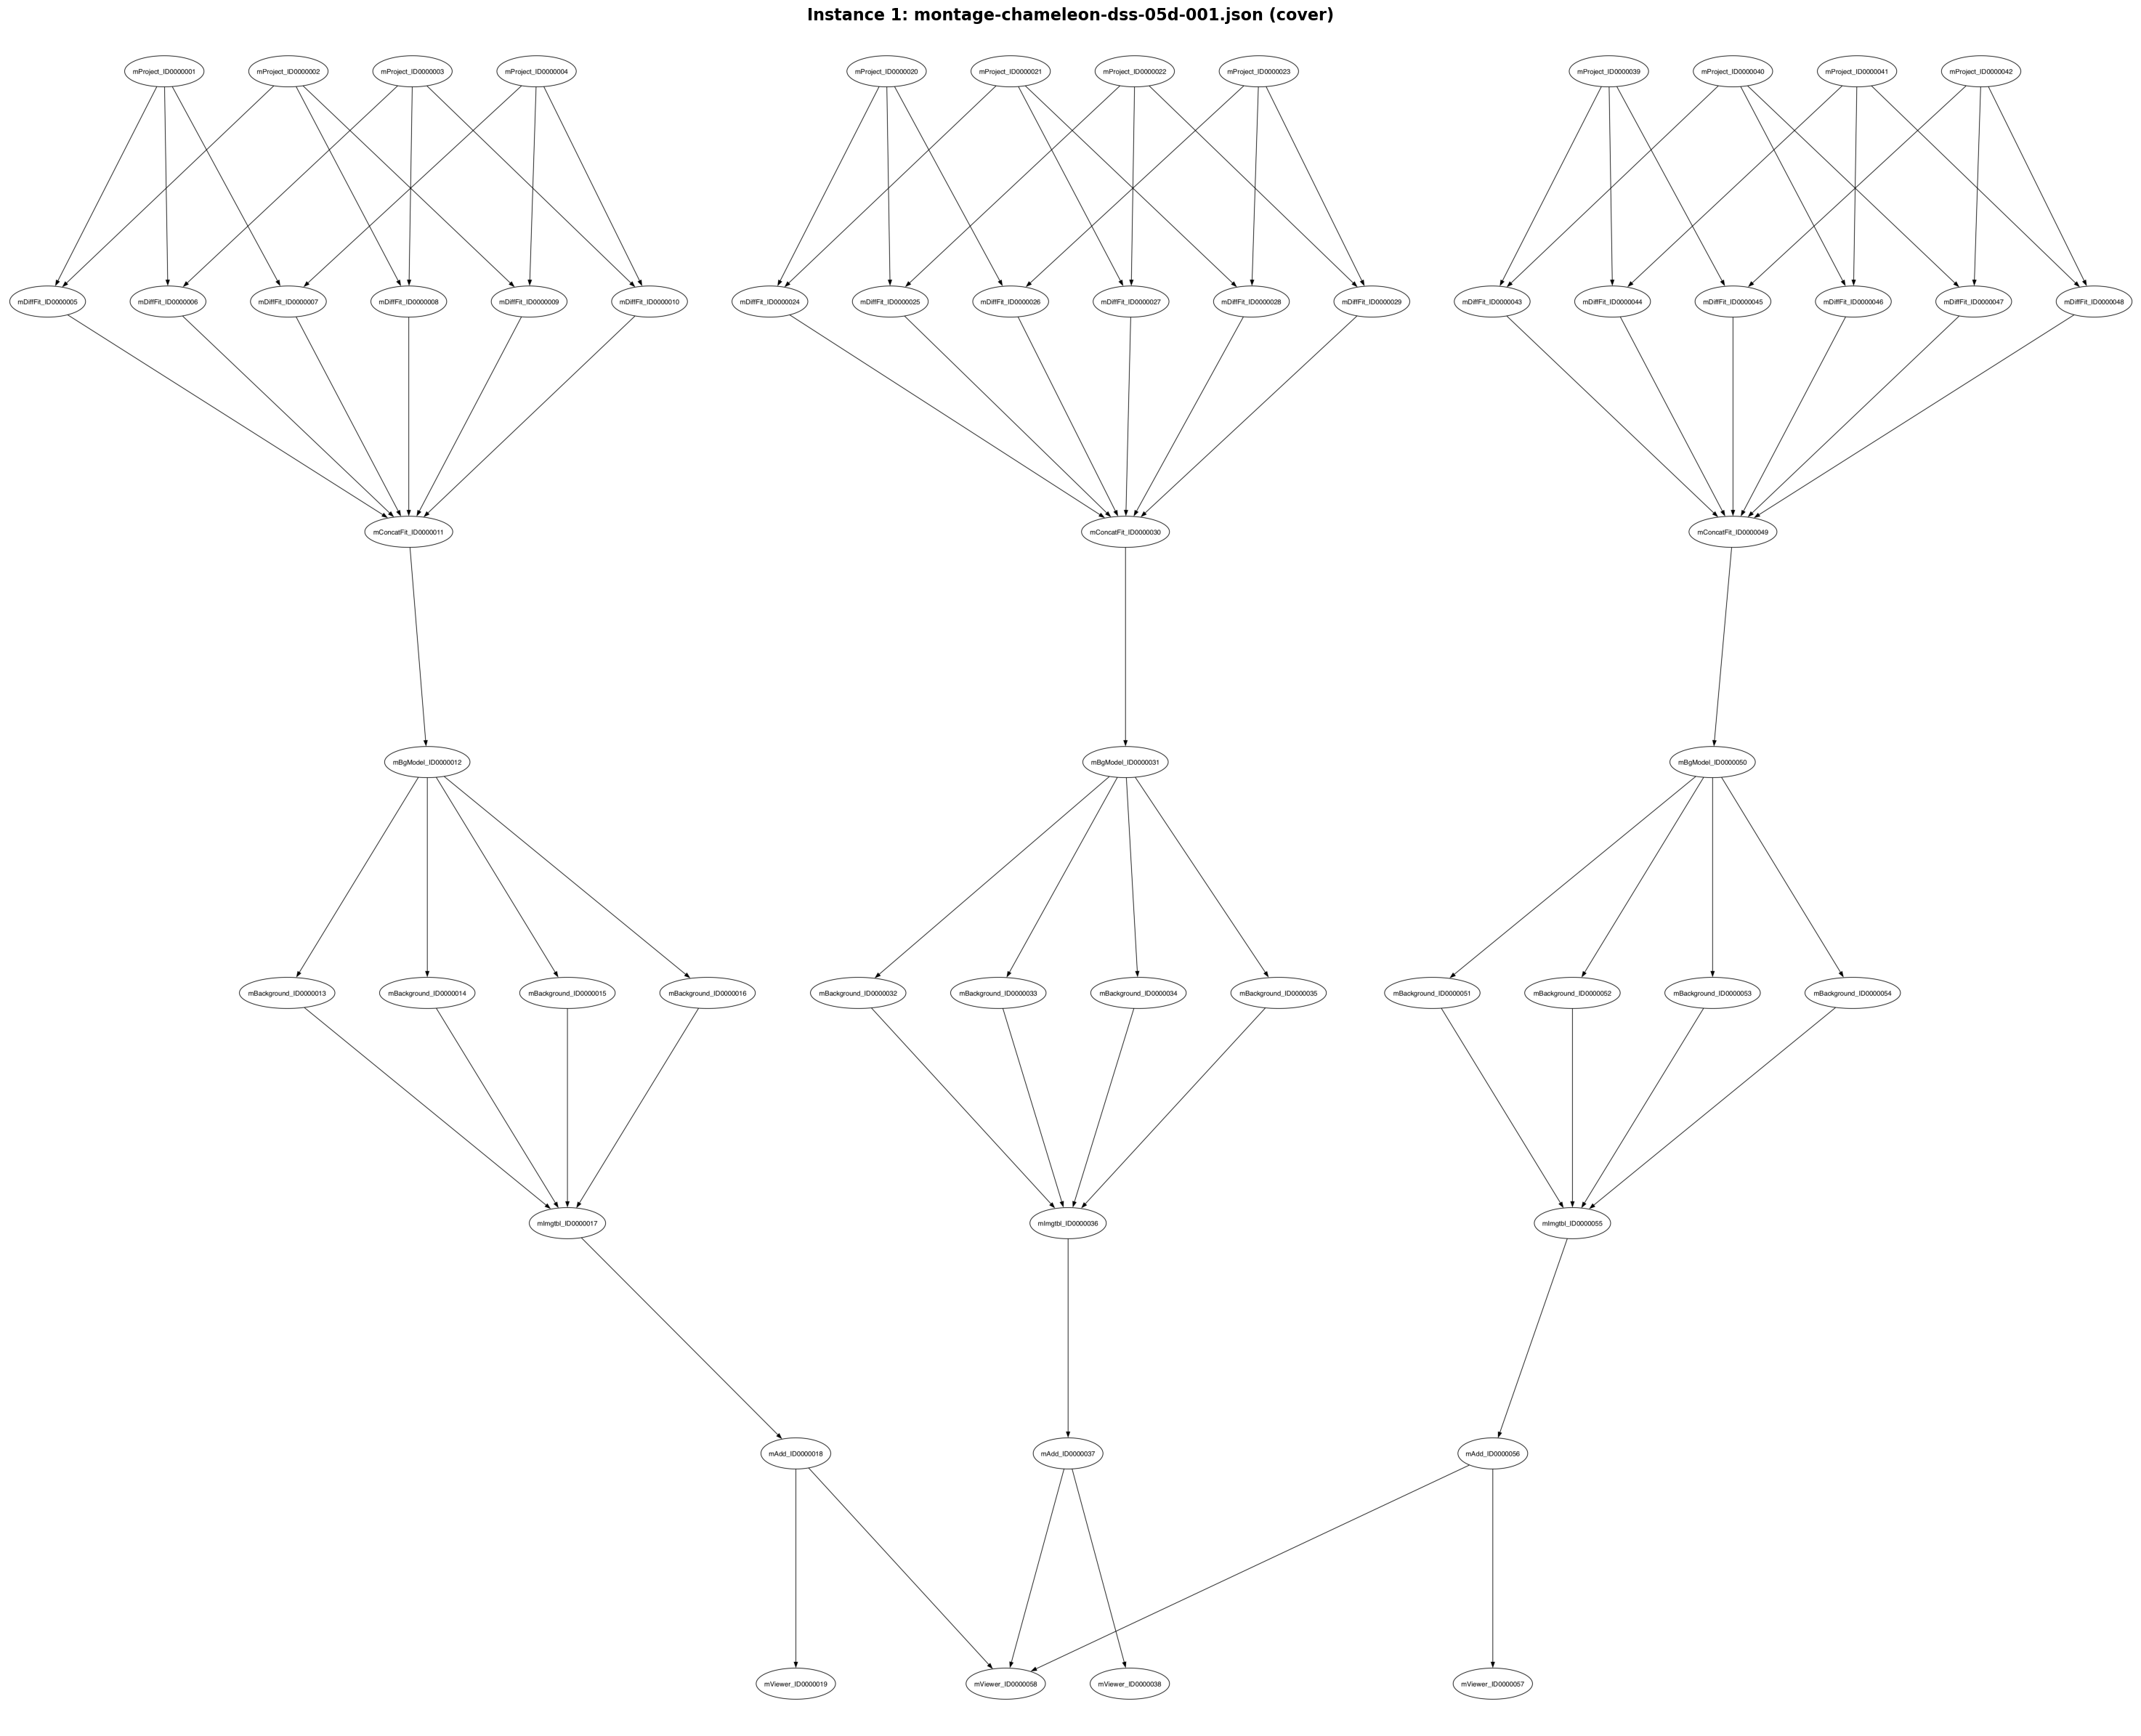

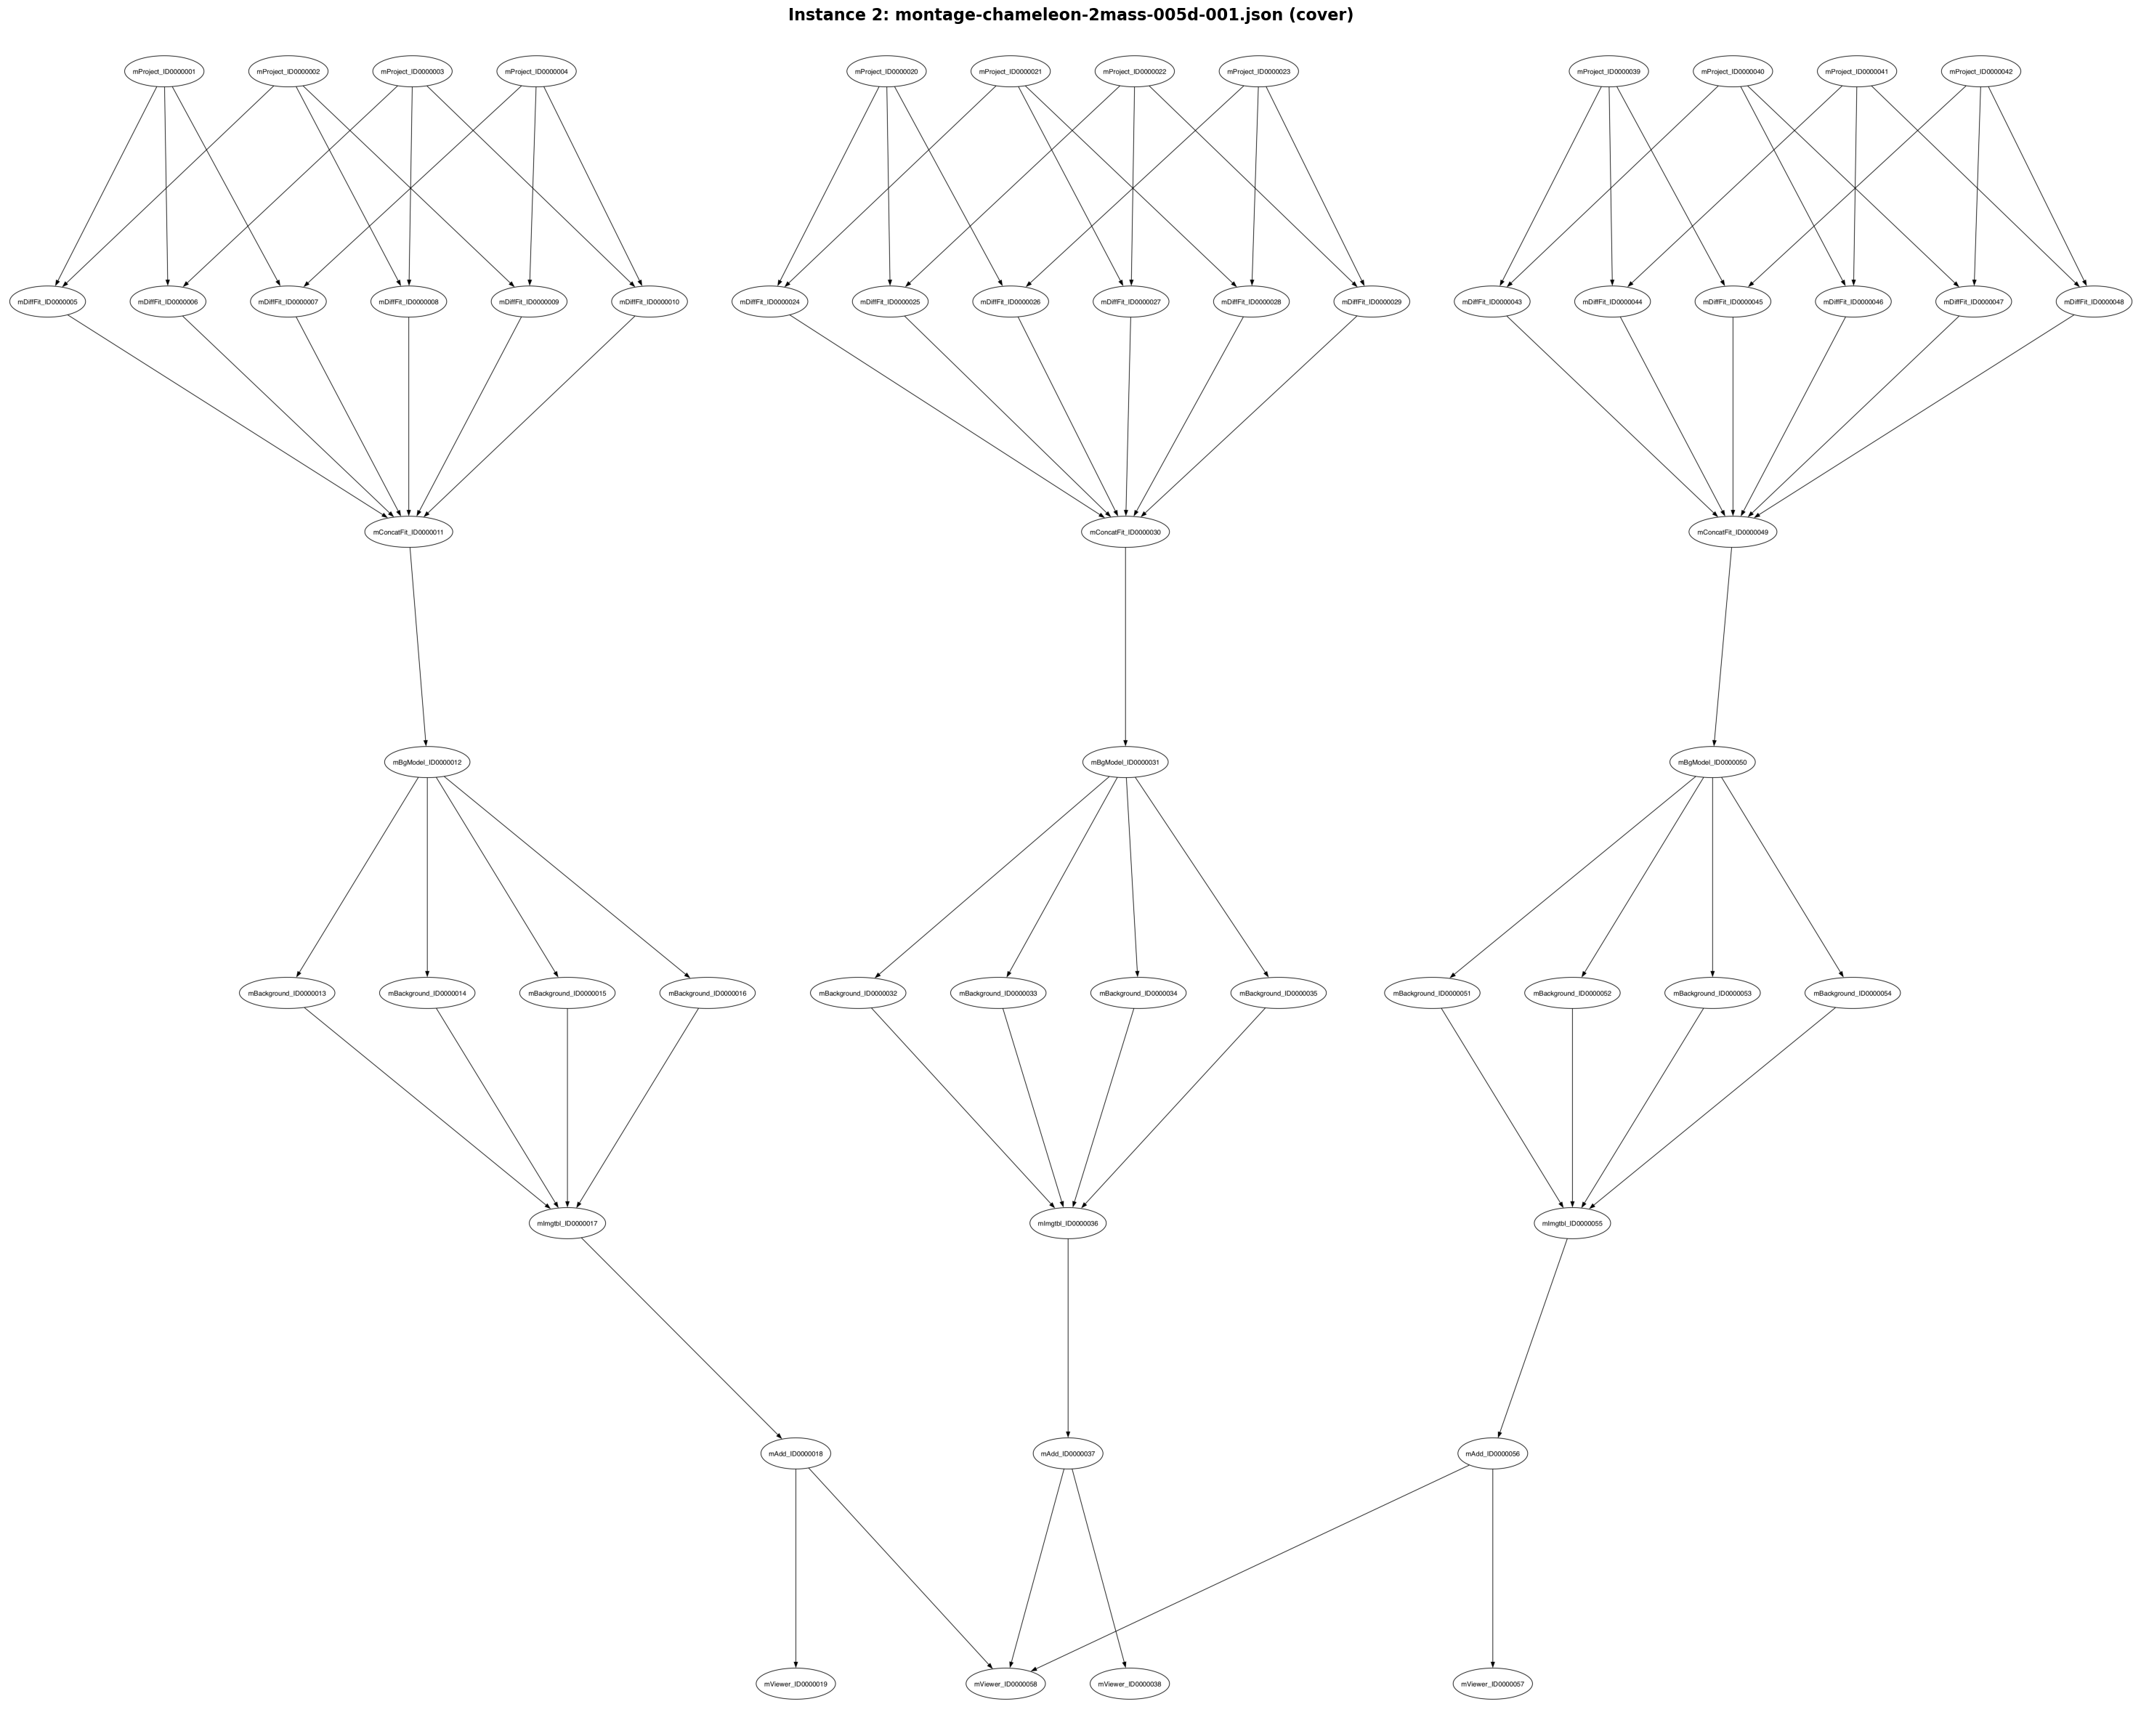

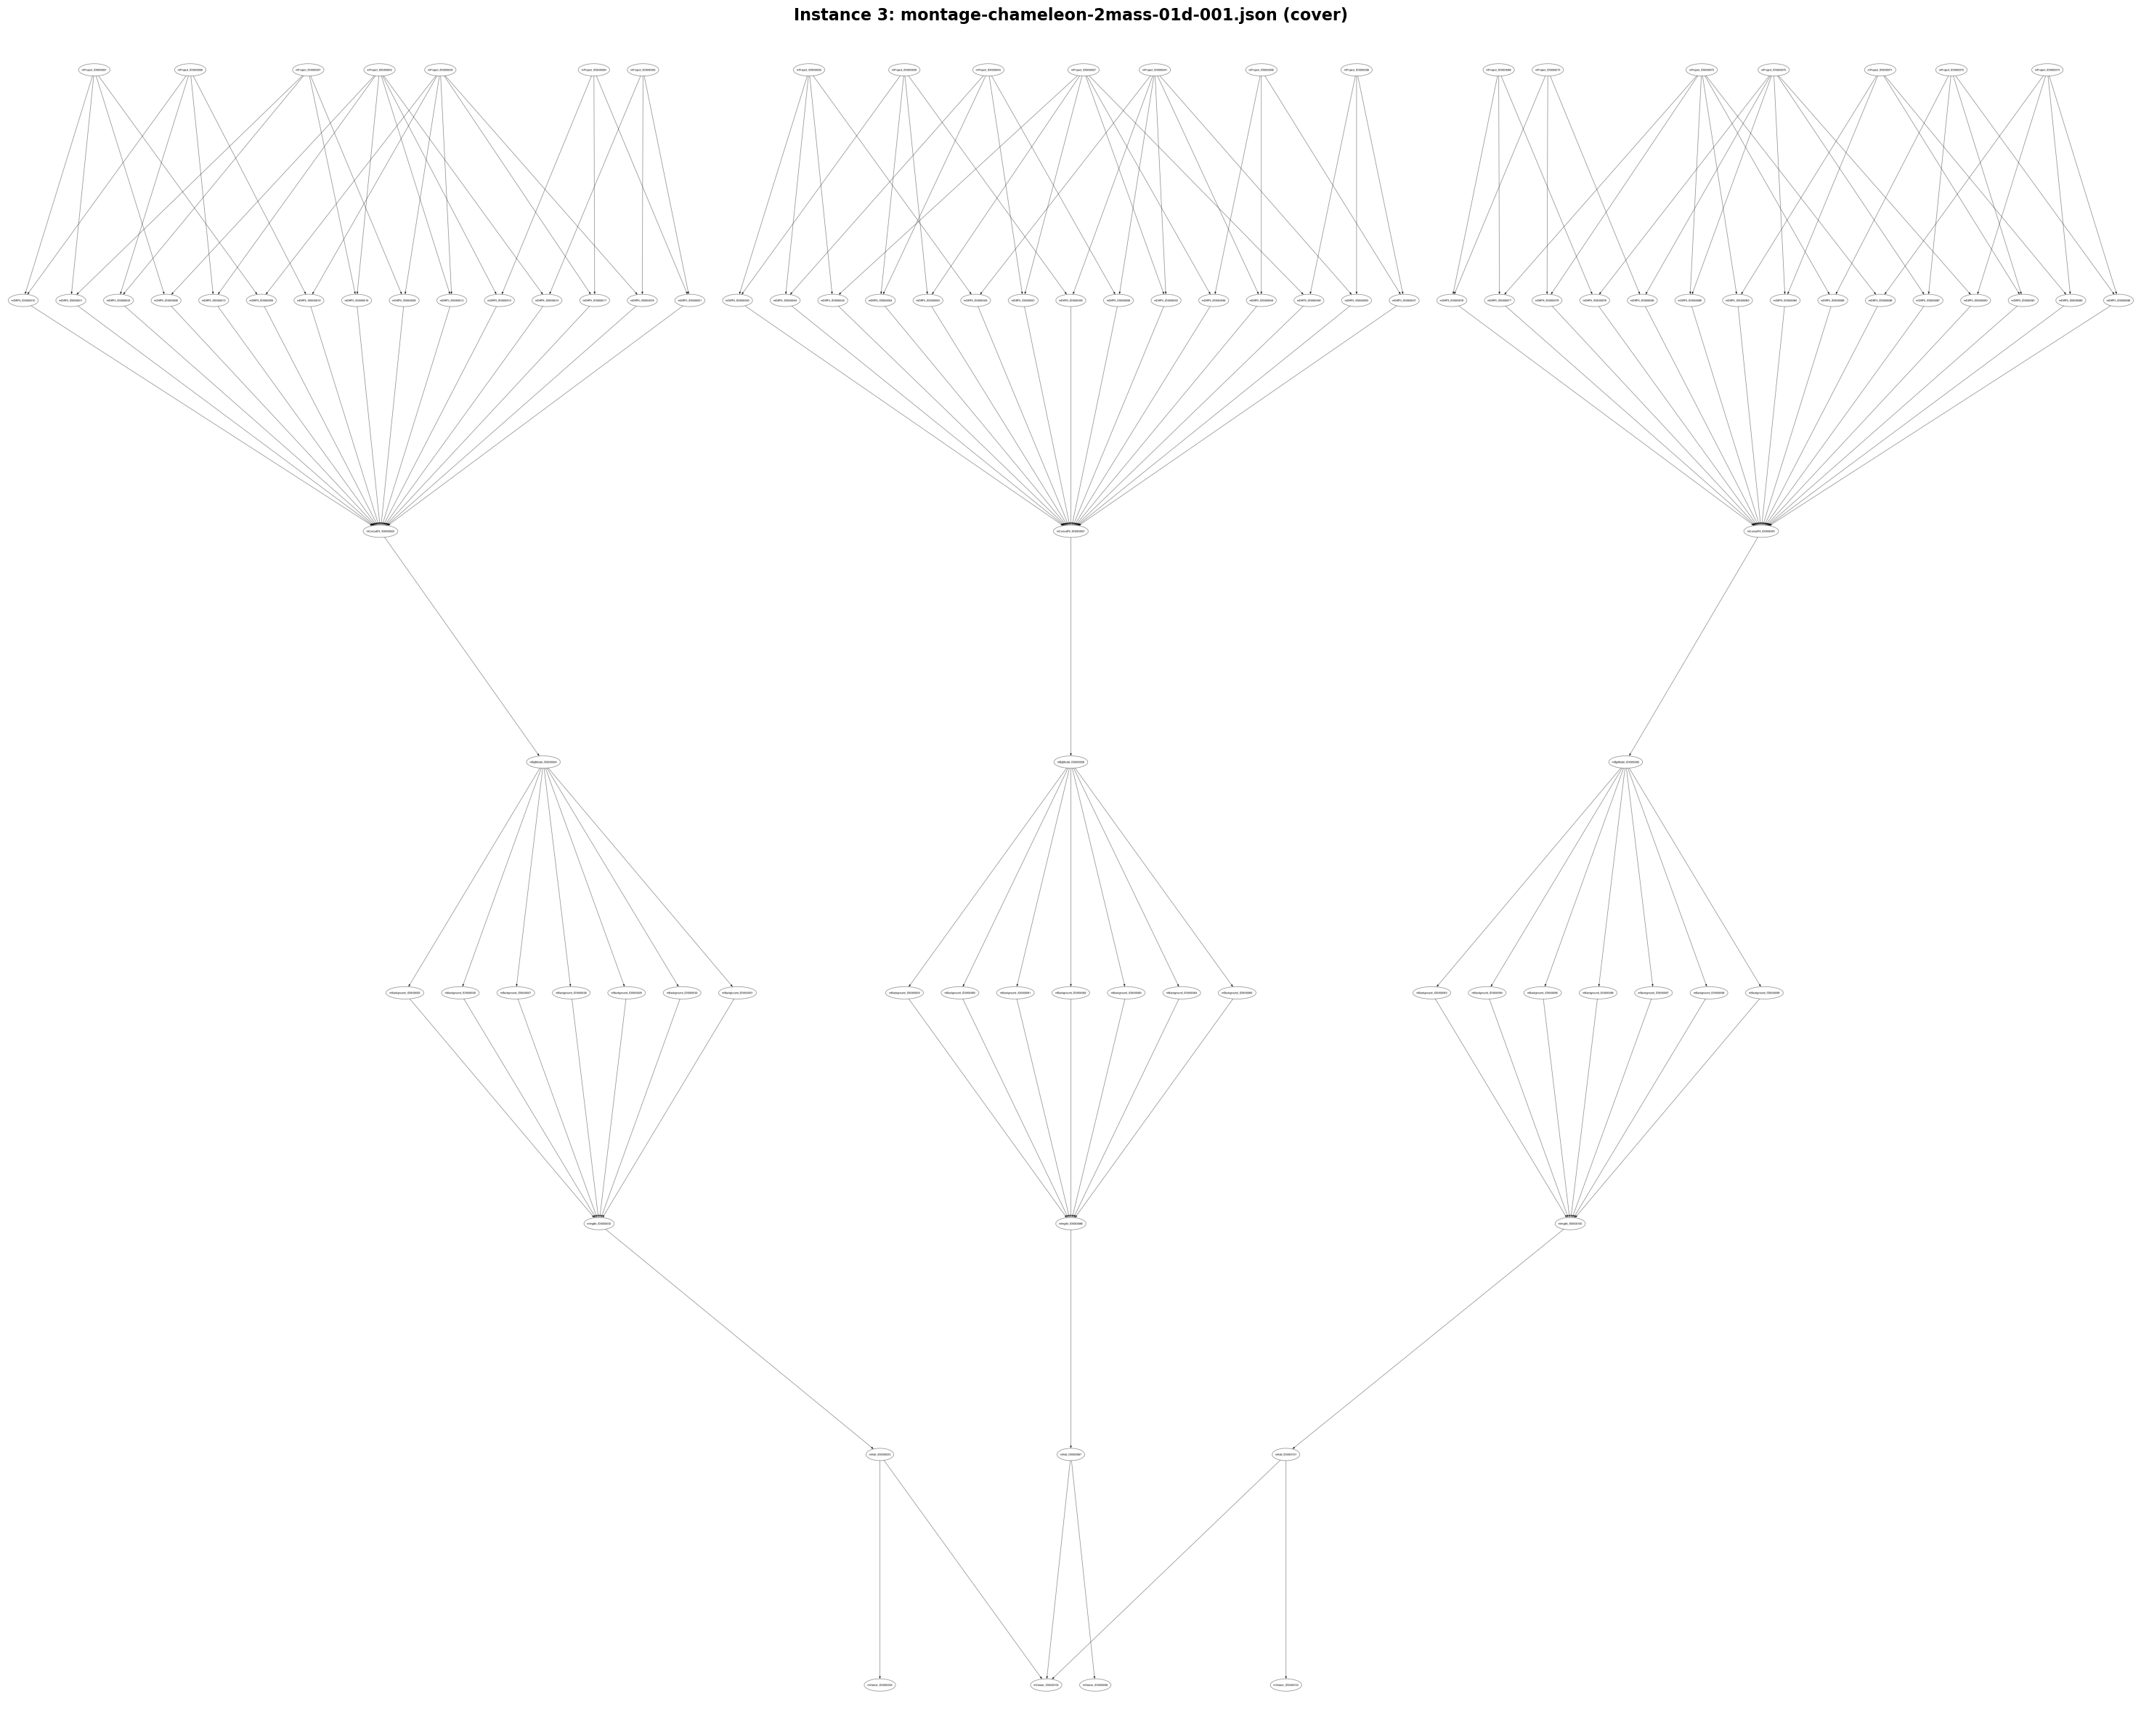

In [5]:
%matplotlib inline
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
print(matplotlib.get_backend())
from src.utils.po_fun_plot import PO_plot
paths = [
    path1,
    path2,
    path3,
]
def _task_ids(inst):
    task_ids = list(inst.get("task_ids") or [])
    if task_ids:
        return task_ids
    parents = inst.get("parents") or {}
    ids = set(parents.keys())
    for ps in parents.values():
        ids.update(ps)
    return sorted(ids)

def _parent_adj(inst):
    task_ids = _task_ids(inst)
    idx = {t: i for i, t in enumerate(task_ids)}
    n = len(task_ids)
    adj = np.zeros((n, n), dtype=int)
    for child, parents in (inst.get("parents") or {}).items():
        if child not in idx:
            continue
        for p in parents:
            if p in idx:
                adj[idx[p], idx[child]] = 1
    return adj, task_ids

for i, path in enumerate(paths, 1):
    inst = load_workflow_instance(path)
    adj, labels = _parent_adj(inst)
    closure = BasicUtils.transitive_closure(adj.astype(np.int8))
    cover = BasicUtils.transitive_reduction_optimized(closure)
    PO_plot.visualize_partial_order(cover, labels, title=f"Instance {i}: {path.name} (cover)")


In [6]:
data_dir = Path("/Users/dongqing/Desktop/hpo_inference_agent/data/wfcommons_wfinstances/montage")
instances = list(iter_workflow_instances(data_dir))
grouped = group_instances(instances)

group_name = "montage-chameleon-2mass-005d"
group_instance_list = grouped.get(group_name, [])
inputs = build_hpo_inputs_from_instances(group_instance_list, prefer_execution_order=True)

# Extract data from inputs
observed_orders = inputs.observed_orders
assessor_id = inputs.assessors[0]
idx_to_task = dict(inputs.idx_to_task)
task_ids = [idx_to_task[i] for i in range(len(idx_to_task))]
parent_sets = {k: set(v) for k, v in inputs.parents_subset.items()}

# Build true adjacency matrix from the group's parent relationships
# This matches the structure used in inputs (task_ids and parent_sets)
true_adj = np.array(build_adjacency_matrix(task_ids, parent_sets), dtype=np.int8)

# Optional: If you need adj and labels for visualization from a single instance,
# you can use the first instance in the group:
if group_instance_list:
    first_instance = group_instance_list[0]
    adj, labels = _parent_adj(first_instance)
# Note: This adj/labels may differ from true_adj if the group has multiple instances

In [7]:

from typing import List, Tuple, Set, Dict


def critical_pairs_from_closure(closure: np.ndarray) -> List[Tuple[int, int]]:
    """
    closure[i,j]=1 means i < j in the poset (strict).
    Returns oriented critical pairs (x,y) that must be reversed by some extension (i.e. y before x).
    """
    C = closure.astype(bool).copy()
    np.fill_diagonal(C, False)
    n = C.shape[0]

    # Down(x) = {z : z < x} = column x
    # Up(x)   = {z : x < z} = row x
    Down = C.T  # Down[x, z] == C[z, x]
    Up   = C

    crit: List[Tuple[int, int]] = []
    for x in range(n):
        Dx = Down[x]
        Ux = Up[x]
        for y in range(n):
            if x == y:
                continue
            if C[x, y] or C[y, x]:
                continue  # comparable => not critical
            Dy = Down[y]
            Uy = Up[y]

            # Dx ⊆ Dy  and  Uy ⊆ Ux
            if np.all(Dx <= Dy) and np.all(Uy <= Ux):
                crit.append((x, y))
    return crit


def _kahn_order_with_priority(
    cover_adj: np.ndarray,
    crit_pairs: List[Tuple[int, int]],
    rng: np.random.Generator,
    *,
    temperature: float = 0.0,
) -> List[int]:
    """
    Build ONE linear extension using a priority rule designed to reverse many critical pairs.
    cover_adj is a DAG adjacency (preferably transitively reduced, but any DAG works).
    crit_pairs are oriented (x,y) meaning we want y before x in this extension if possible.

    temperature=0 -> greedy max priority
    temperature>0 -> softmax sampling among frontier based on priority
    """
    A = (cover_adj != 0)
    n = A.shape[0]
    succ = [np.flatnonzero(A[u]).tolist() for u in range(n)]
    indeg = A.sum(axis=0).astype(int)

    # Build "desire" counts: for (x,y) we want y early and x late
    want_early = np.zeros(n, dtype=int)  # y appears here
    want_late  = np.zeros(n, dtype=int)  # x appears here
    for x, y in crit_pairs:
        want_early[y] += 1
        want_late[x]  += 1

    frontier = [i for i in range(n) if indeg[i] == 0]
    order: List[int] = []

    # Greedy/softmax selection from frontier
    while frontier:
        # Priority: push y early, delay x
        scores = np.array([want_early[v] - want_late[v] for v in frontier], dtype=float)

        if temperature <= 0.0:
            best = np.max(scores)
            candidates = [frontier[i] for i, s in enumerate(scores) if s == best]
            chosen = int(rng.choice(candidates))
        else:
            # softmax
            scores = scores - scores.max()
            w = np.exp(scores / temperature)
            w = w / w.sum()
            chosen = int(rng.choice(frontier, p=w))

        # remove chosen from frontier
        frontier.remove(chosen)
        order.append(chosen)

        # update graph
        for v in succ[chosen]:
            indeg[v] -= 1
            if indeg[v] == 0:
                frontier.append(v)

    if len(order) != n:
        raise ValueError("Graph had a cycle or was not fully processed.")
    return order


def _covered_critical_pairs(order: List[int], crit_pairs: List[Tuple[int, int]]) -> Set[int]:
    """Return indices of critical pairs (x,y) that are reversed in this order (i.e., y before x)."""
    pos = {v: i for i, v in enumerate(order)}
    covered: Set[int] = set()
    for k, (x, y) in enumerate(crit_pairs):
        if pos[y] < pos[x]:
            covered.add(k)
    return covered


def greedy_realizer(
    cover_adj: np.ndarray,
    closure: np.ndarray,
    *,
    seed: int = 0,
    max_extensions: int = 50,
    temperature: float = 0.5,
) -> List[List[int]]:
    """
    Greedy construction of a small realizer-like set:
      - compute critical pairs
      - iteratively add extensions that cover many uncovered critical pairs

    Not guaranteed minimal, but usually small and very informative.
    """
    rng = np.random.default_rng(seed)
    crit = critical_pairs_from_closure(closure)
    if not crit:
        # Total order already -> one extension is enough
        return [_kahn_order_with_priority(cover_adj, [], rng)]

    uncovered = set(range(len(crit)))
    realizers: List[List[int]] = []

    for _ in range(max_extensions):
        # build an extension guided by ALL critical pairs (heuristic)
        order = _kahn_order_with_priority(cover_adj, crit, rng, temperature=temperature)
        cov = _covered_critical_pairs(order, crit)
        gain = cov & uncovered
        if gain:
            realizers.append(order)
            uncovered -= gain
        # stop if all critical pairs reversed somewhere
        if not uncovered:
            break

    return realizers


def intersection_poset_from_extensions(extensions: List[List[int]], n: int) -> np.ndarray:
    """
    Returns strict relation R where R[i,j]=1 iff i before j in *every* extension.
    """
    R = np.ones((n, n), dtype=bool)
    np.fill_diagonal(R, False)
    for order in extensions:
        pos = np.empty(n, dtype=int)
        pos[np.array(order, dtype=int)] = np.arange(n)
        before = pos[:, None] < pos[None, :]
        np.fill_diagonal(before, False)
        R &= before
    return R.astype(np.int8)


In [8]:
true_closure = BasicUtils.transitive_closure(true_adj.astype(np.int8))
true_cover   = BasicUtils.transitive_reduction_optimized(true_closure.astype(np.int8))

extensions = greedy_realizer(
    cover_adj=true_cover,
    closure=true_closure,
    seed=seed,
    max_extensions=10000,
    temperature=1.0,
)

print("num extensions:", len(extensions))

# Verify (very important!):
R = intersection_poset_from_extensions(extensions, n=true_closure.shape[0])
ok = np.array_equal(R, true_closure.astype(np.int8))
print("intersection == true_closure ?", ok)


# assumes critical_pairs_from_closure() is defined

crit = critical_pairs_from_closure(true_closure)

def covered_crit_pairs(order, crit_pairs):
    pos = {v: i for i, v in enumerate(order)}
    covered = set()
    for k, (x, y) in enumerate(crit_pairs):
        if pos[y] < pos[x]:  # reversed as required
            covered.add(k)
    return covered

covered = set()
for order in extensions:
    covered |= covered_crit_pairs(order, crit)

print(f"critical pairs total={len(crit)} covered={len(covered)} frac={len(covered)/max(1,len(crit)):.3f}")

missing = [crit[i] for i in sorted(set(range(len(crit))) - covered)]
print(f"missing critical pairs: {len(missing)}")
if missing:
    print("example missing:", missing[:10])



num extensions: 12
intersection == true_closure ? True
critical pairs total=99 covered=99 frac=1.000
missing critical pairs: 0


In [ ]:
real_trace = inputs.observed_orders[assessor_id][0]
orders = [list(real_trace)] + [list(o) for o in extensions]

In [ ]:
target_traces = 50
orders = list(extensions)
synthetic_beta = 1.0
synthetic_epsilon = 0.01
lambda_penalty = 1.0
epsilon_scope = "frontier"
strict = True
frontier_random = True

rng = np.random.default_rng(seed)

def sample_frontier_softmax_trace(H, beta, epsilon, rng, lambda_penalty, strict, frontier_random, epsilon_scope):
    H_bool = H.astype(bool)
    n = H_bool.shape[0]
    successors = [np.flatnonzero(H_bool[u]).tolist() for u in range(n)]
    indeg = H_bool.sum(axis=0).astype(int).tolist()

    # canonical order for ranking
    order = []
    frontier = [i for i in range(n) if indeg[i] == 0]
    remaining = set(range(n))
    remaining_order = list(range(n))

    while remaining:
        if not frontier:
            break
        rank = {a: i for i, a in enumerate(remaining_order)}
        if strict:
            chosen = rng.choice(frontier) if frontier_random else min(frontier, key=lambda a: rank[a])
        else:
            if rng.random() < epsilon:
                chosen = rng.choice(frontier) if epsilon_scope == "frontier" else rng.choice(list(remaining))
            else:
                scores = np.array([-beta * lambda_penalty * rank[a] for a in frontier], dtype=float)
                scores -= scores.max()
                w = np.exp(scores)
                w /= w.sum()
                chosen = rng.choice(frontier, p=w)

        frontier.remove(chosen)
        order.append(chosen)
        remaining.remove(chosen)
        remaining_order.remove(chosen)
        for v in successors[chosen]:
            indeg[v] -= 1
            if indeg[v] == 0:
                frontier.append(v)
    return order

# ensure uniqueness (optional)
seen = {tuple(o) for o in orders}
while len(orders) < target_traces:
    o = sample_frontier_softmax_trace(
        true_closure,
        beta=synthetic_beta,
        epsilon=synthetic_epsilon,
        rng=rng,
        lambda_penalty=lambda_penalty,
        strict=strict,
        frontier_random=frontier_random,
        epsilon_scope=epsilon_scope,
    )
    if tuple(o) in seen:
        continue
    orders.append(o)
    seen.add(tuple(o))

In [17]:
num_iterations = 3000000
burn_in_fraction = 0.5


# Load helpers from wfcommons_montage_recovery.py (so canonical/summary are defined)
helpers = runpy.run_path(str(project_root / "notebooks/wfcommons_montage_recovery.py"))
_canonical_order_from_adj = helpers["_canonical_order_from_adj"]
_summarize_trace_distribution = helpers["_summarize_trace_distribution"]
M0 = list(inputs.M0) 
assessor_id = inputs.assessors[0]
n = len(M0)
observed_orders = {assessor_id: orders[:target_traces]}
O_a_i_dict = {assessor_id: [sorted(M0)] * len(observed_orders[assessor_id])}
M_a_dict = {assessor_id: list(M0)}

uniq = len({tuple(o) for o in orders})
print(f"unique traces: {uniq}/{len(orders)}")

canonical = _canonical_order_from_adj(true_closure)
trace_stats = _summarize_trace_distribution(
    orders,
    len(M0),
    true_cover=true_cover,
    canonical_order=canonical,
)
summary = {k: trace_stats[k] for k in [
    "num_traces",
    "num_unique",
    "unique_fraction",
    "pair_entropy_mean",
    "pair_entropy_std",
    "pair_coverage_mean",
    "edge_precedence_mean",
    "nonedge_precedence_mean",
]}
print(json.dumps(summary, indent=2))

# --- MCMC using these realizers as the only traces ---
mcmc_results = mcmc_simulation_hpo_k_optim(
    num_iterations=num_iterations ,  # change if needed
    M0=M0,
    assessors=[assessor_id],
    M_a_dict=M_a_dict,
    O_a_i_dict=O_a_i_dict,
    observed_orders=observed_orders,
    dr=0.95,
    drrt=0.95,
    noise_option="softmax_queue_jump",
    rho_prior=1.0,
    noise_beta_prior=1.0,
    K_prior=2,
    fixed_K=None,          # RJMCMC
    random_seed=seed,
    cycle_length=500,
    softmax_lambda=1.0,
    softmax_beta_prior=(2.0, 1.0),
    softmax_beta_stepsize=0.1,
)

unique traces: 50/50
{
  "num_traces": 50,
  "num_unique": 50,
  "unique_fraction": 1.0,
  "pair_entropy_mean": 0.38500500377701674,
  "pair_entropy_std": 0.2783115422509354,
  "pair_coverage_mean": 1.0,
  "edge_precedence_mean": 1.0,
  "nonedge_precedence_mean": 0.48600746268656714
}
📊 Update Schedule Frequencies: {'U0': 191, 'Ua': 94, 'rho': 6, 'tau': 9, 'rho_tau': 6, 'noise': 6, 'K': 188}
📋 Sequential update cycle length: 500
Iteration 150000/3000000 - Accept Rate: 43.24%
Iteration 300000/3000000 - Accept Rate: 42.18%
Iteration 450000/3000000 - Accept Rate: 41.77%
Iteration 600000/3000000 - Accept Rate: 41.54%
Iteration 750000/3000000 - Accept Rate: 41.35%
Iteration 900000/3000000 - Accept Rate: 41.22%
Iteration 1050000/3000000 - Accept Rate: 41.07%
Iteration 1200000/3000000 - Accept Rate: 40.98%
Iteration 1350000/3000000 - Accept Rate: 40.97%
Iteration 1500000/3000000 - Accept Rate: 40.94%
Iteration 1650000/3000000 - Accept Rate: 40.89%
Iteration 1800000/3000000 - Accept Rate: 40.8

module://matplotlib_inline.backend_inline
Excluding 500000 burn-in iterations


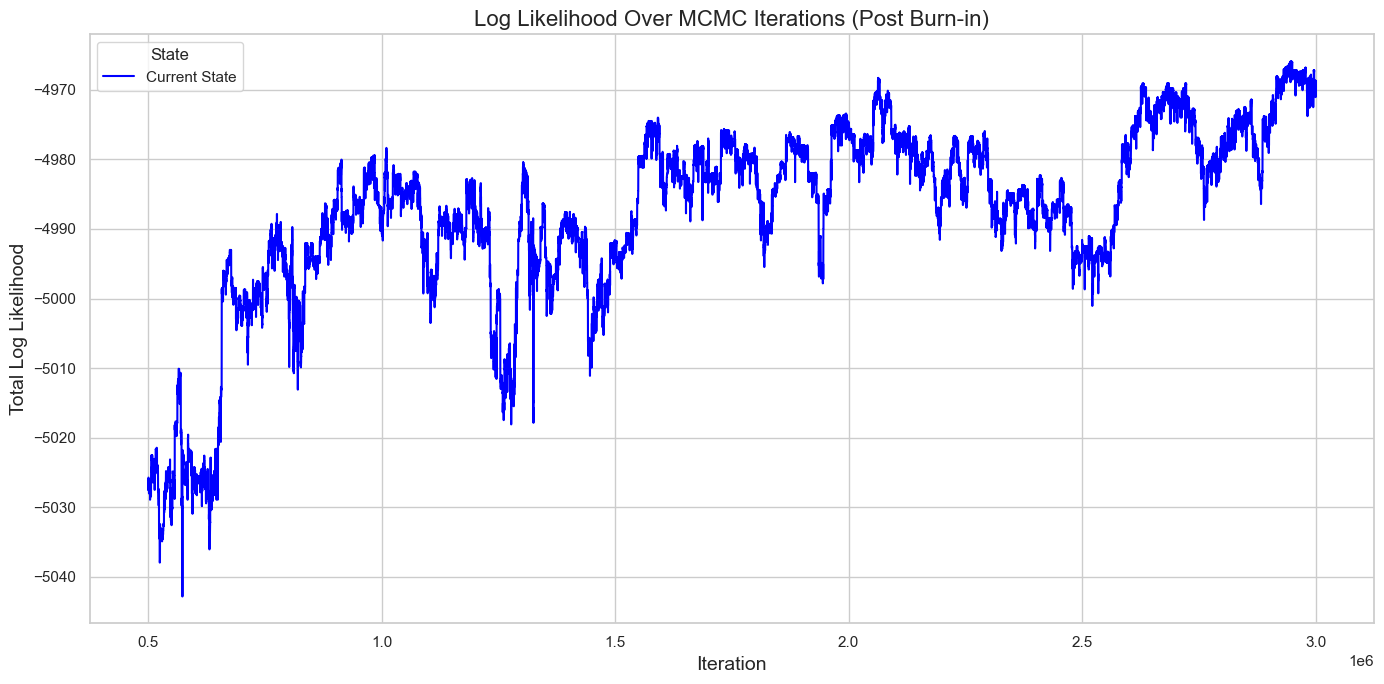

In [18]:
%matplotlib inline
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
print(matplotlib.get_backend())

log_likelihood_currents = mcmc_results.get('log_likelihood_currents', [])
PO_plot.plot_log_likelihood(log_likelihood_currents,burn_in=500000)

In [30]:
inputs = build_hpo_inputs_from_instances(group_instance_list, prefer_execution_order=True)
print(inputs.assessors)          # -> [1]
print(inputs.observed_orders.keys())  # should include 1
assessor_id = inputs.assessors[0]

[1]
dict_keys([1])


[INFO] Saved inferred parameters plot to './posterior_inference_result.pdf'


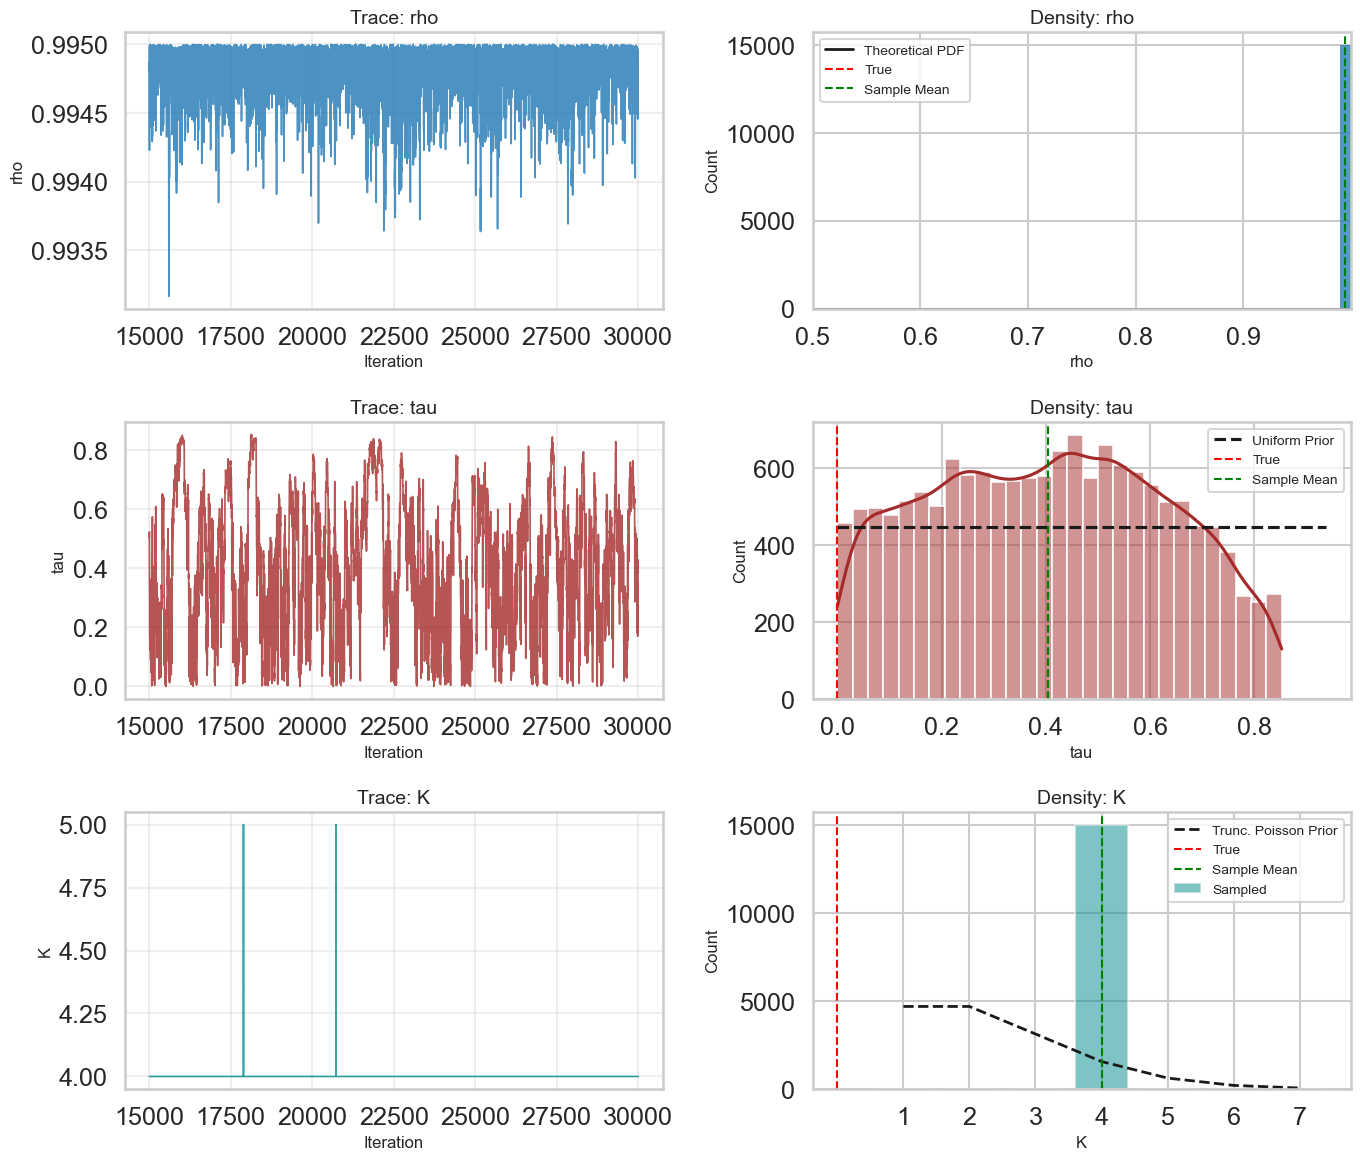

In [31]:

from src.utils.po_fun_plot import PO_plot

# ---- fill these with your values ----
true_param_k = {
    "rho_true": 0,
    "prob_noise_true": 0,
    "tau_true": 0,
    "beta_true": 0,
    "K_true": 0,
}

config = {
    "prior": {
        "rho_prior": 1.0,
        "K_prior": 2,  # or your prior setting
    },
    "noise": {
        "noise_option": "softmax_queue_jump",
    },
}

burn_in_k = int(len(mcmc_results.get("H_trace", [])) * 0.5)  # or your chosen burn-in

# Optional: filter MCMC results if you already did; otherwise use mcmc_results_k directly
filtered_mcmc_results= mcmc_results

# ---- plots ----
PO_plot.plot_inferred_variables(
    filtered_mcmc_results,
    true_param_k,
    config,
    burn_in=burn_in_k,
    output_filename= "posterior_inference_result.pdf",
    assessors=inputs.assessors,
    M_a_dict=M_a_dict,
)



Text(0, 0.5, 'count')

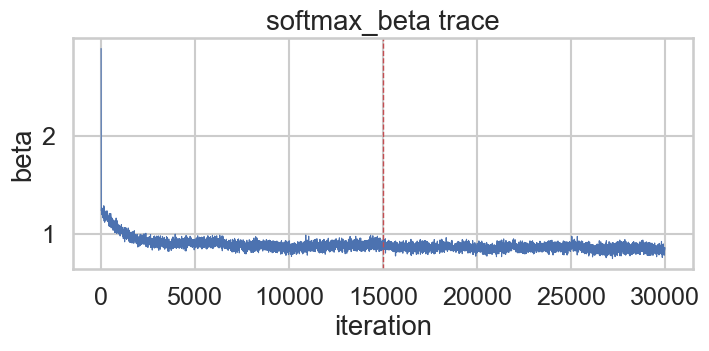

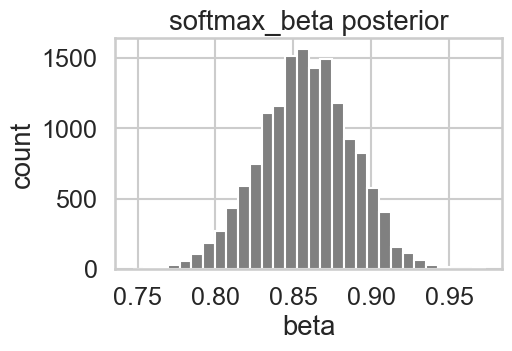

In [32]:
beta = np.array(mcmc_results.get("softmax_beta_trace", []), dtype=float)
burn = int(len(beta) * 0.5)

plt.figure(figsize=(8, 3))
plt.plot(beta, lw=0.8)
plt.axvline(burn, color="r", ls="--", lw=1)
plt.title("softmax_beta trace")
plt.xlabel("iteration"); plt.ylabel("beta")

plt.figure(figsize=(5, 3))
plt.hist(beta[burn:], bins=30, color="gray")
plt.title("softmax_beta posterior")
plt.xlabel("beta"); plt.ylabel("count")


In [33]:
import seaborn as sns

def plot_top_partial_orders(top_percentages, top_n=4, item_labels=None, max_labels=15):
    """
    Plot the top N partial orders as heatmaps with their corresponding frequencies and percentages.
    
    Parameters:
    -----------
    top_percentages : List[Tuple[np.ndarray, int, float]]
        List of tuples containing (partial_order_matrix, count, percentage).
    top_n : int, optional
        Number of top partial orders to plot (default: 4).
    item_labels : List[str], optional
        List of labels for the items. If None, numerical indices are used.
    max_labels : int, optional
        Maximum number of items to show labels for. If matrix is larger, labels are hidden (default: 15).
    """
    if not top_percentages:
        print("Warning: top_percentages is empty. Nothing to plot.")
        return
    
    # Get matrix size from first partial order
    first_matrix = top_percentages[0][0]
    n_items = first_matrix.shape[0]
    
    # Determine if we should show labels
    show_labels = item_labels is not None and n_items <= max_labels
    display_labels = item_labels if show_labels else [str(i) for i in range(n_items)] if n_items <= max_labels else False
    
    # Calculate font sizes based on matrix size
    annot_fontsize = max(6, min(10, int(120 / max(1, n_items))))
    label_fontsize = max(7, min(10, int(140 / max(1, n_items))))
    
    # Determine the layout of subplots
    n_cols = 2  # Number of columns in the subplot grid
    n_rows = (top_n + n_cols - 1) // n_cols  # Ceiling division for rows
    
    # Adjust figure size based on number of items
    fig_width = max(8, min(12, 5 * n_cols + n_items * 0.3))
    fig_height = max(6, min(10, 4 * n_rows + n_items * 0.2))
    plt.figure(figsize=(fig_width, fig_height))
    
    for idx, (order, count, percentage) in enumerate(top_percentages[:top_n], 1):
        ax = plt.subplot(n_rows, n_cols, idx)
        
        # Get matrix size for this specific matrix (in case sizes differ)
        current_n_items = order.shape[0]
        
        # Determine if we should annotate (show numbers in cells)
        # Only annotate if matrix is small enough
        annot = current_n_items <= 10
        
        # Get labels for this matrix size
        if show_labels and current_n_items == n_items:
            # Use the precomputed labels if sizes match
            current_labels = display_labels
        elif item_labels is not None and current_n_items <= max_labels:
            # Use provided labels if available and matrix is small enough
            current_labels = item_labels[:current_n_items] if len(item_labels) >= current_n_items else [str(i) for i in range(current_n_items)]
        elif current_n_items <= max_labels:
            # Use numeric indices if small enough
            current_labels = [str(i) for i in range(current_n_items)]
        else:
            # Hide labels for large matrices
            current_labels = False
        
        # Calculate font size for this matrix
        current_annot_fontsize = max(6, min(10, int(120 / max(1, current_n_items))))
        
        # Black & white heatmap
        sns.heatmap(
            order, 
            annot=annot,
            fmt="d", 
            cmap="Greys",  # Black & white
            cbar=False, 
            linewidths=0.3, 
            linecolor='gray',
            xticklabels=current_labels,
            yticklabels=current_labels,
            annot_kws={'size': current_annot_fontsize} if annot else {},
            ax=ax
        )
        
        ax.set_title(f"Top {idx}: {percentage:.1f}% (n={count})", fontsize=10, fontweight='bold')
        
        # Rotate x-axis labels for readability if showing labels
        if current_labels:
            current_label_fontsize = max(7, min(10, int(140 / max(1, current_n_items))))
            ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=current_label_fontsize)
            ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=current_label_fontsize)
        
        ax.set_xlabel("")
        ax.set_ylabel("")
    
    # Remove any empty subplots
    total_plots = n_rows * n_cols
    if top_n < total_plots:
        for empty_idx in range(top_n + 1, total_plots + 1):
            plt.subplot(n_rows, n_cols, empty_idx)
            plt.axis('off')
    
    plt.tight_layout()
    plt.show()


Assessor 0: 25000 post‑burn samples


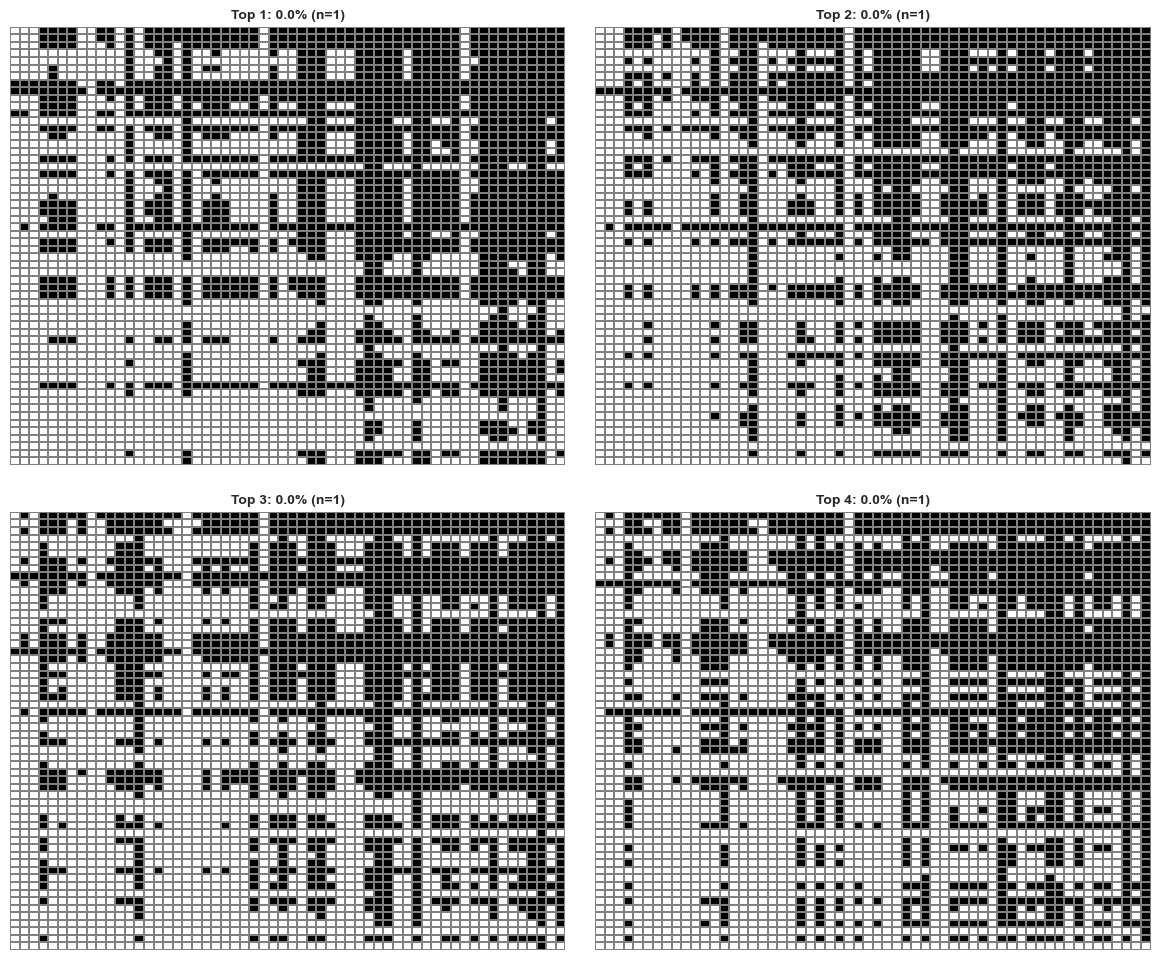

Assessor 1: 25000 post‑burn samples


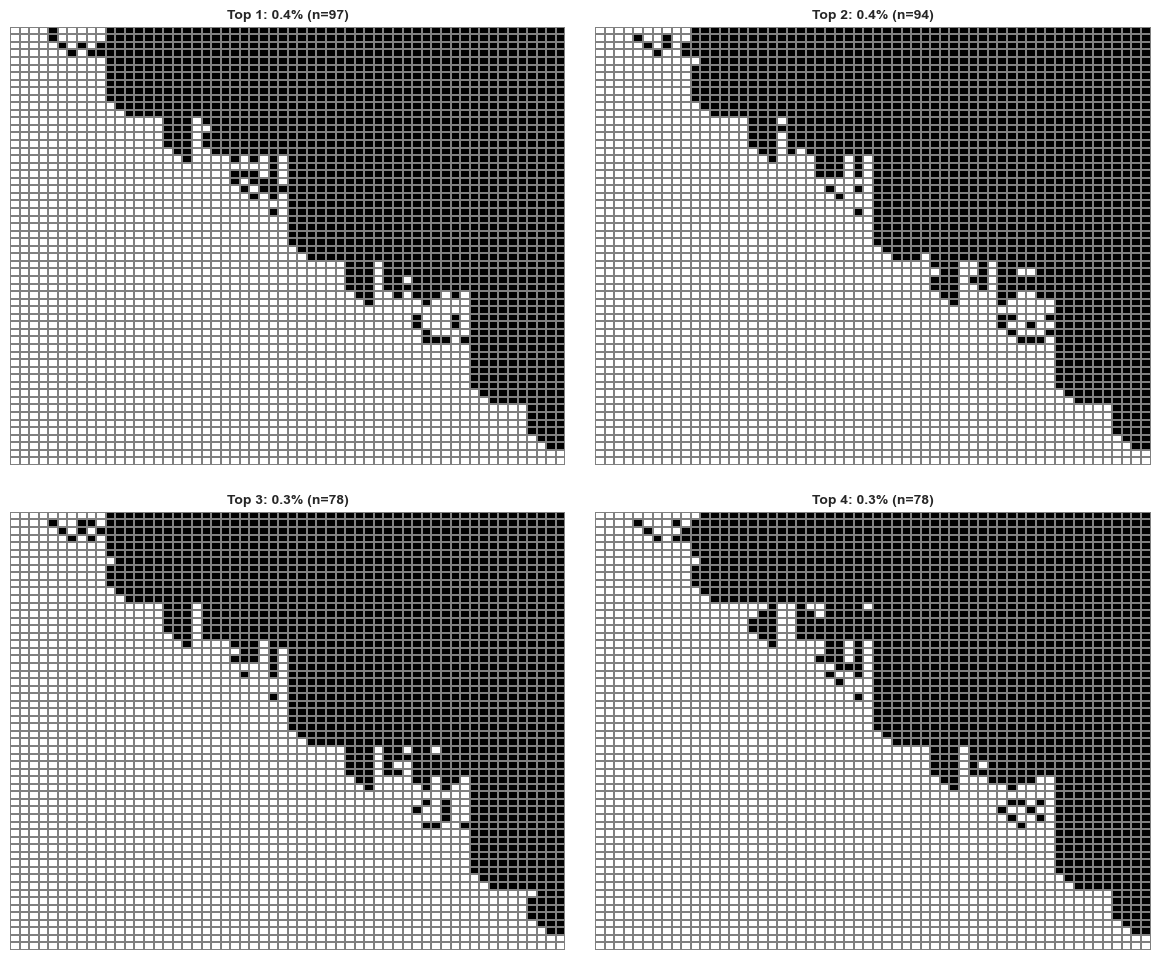

In [34]:
from src.utils.po_fun import StatisticalUtils
burn_in_k = int(500000/ 100)  # Convert to integer (1000 instead of 1000.0)

h_trace_k       = mcmc_results["H_trace"][burn_in_k:]

filtered_mcmc_results_k = {
    key: trace[burn_in_k:] if isinstance(trace, np.ndarray) else trace
    for key, trace in mcmc_results.items()
}

threshold = 0.5

# Create a new dictionary to store the final inferred binary partial orders.
final_H_k = {}
# Get all assessor IDs from the first iteration
assessor_ids_k = h_trace_k[0].keys() 
for a in assessor_ids_k:
    # collect every iteration’s matrix for this assessor
    mats_a = [h_iter[a] for h_iter in h_trace_k if a in h_iter]

    mean_mat   = np.mean(mats_a, axis=0)
    bin_mat    = (mean_mat >= threshold).astype(int)
    h_final_a  = BasicUtils.transitive_reduction(bin_mat)
    final_H_k[a] = h_final_a

    # ---- frequency diagnostics --------------------------------
    sorted_hist = StatisticalUtils.count_unique_partial_orders(mats_a)
    total = sum(cnt for _, cnt in sorted_hist)
    print(f"Assessor {a}: {total} post‑burn samples")

    top_n = 4
    top_orders = sorted_hist[:top_n]
    top_perc   = [(m, c, 100*c/total) for m, c in top_orders]
    plot_top_partial_orders(top_perc, top_n=top_n, item_labels=M0)


In [36]:

from collections import Counter, defaultdict
from typing import List, Dict, Any, Optional

def build_final_partial_orders(
    h_trace: List[Dict[Any, np.ndarray]],
    *,
    method: str = "mode",              # "mode" or "threshold"
    threshold: float = 0.3,            # used only when method="threshold"
    top_n: int = 4,
    item_labels: Optional[List[Any]] = None,
    plot_top: bool = True,
) -> Dict[Any, np.ndarray]:
    """
    Aggregate per-assessor partial orders into final H matrices.
    
    Parameters
    ----------
    h_trace : list of dict
        Each element is a dict {assessor_id -> adjacency matrix} for that iteration.
    method : {"mode", "threshold"}
        - "mode": choose the most frequent relationship per edge (i→j, j→i, incomparable).
        - "threshold": average probability and threshold at `threshold`.
    threshold : float
        Mean threshold when method="threshold".
    top_n : int
        Number of most frequent partial orders to show in diagnostics.
    item_labels : list, optional
        Labels to display in plots (falls back to 0..n-1).
    plot_top : bool
        Show top-N partial orders via `PO_plot` if available.
    
    Returns
    -------
    final_H : dict
        {assessor_id -> final adjacency matrix (after transitive reduction)}.
    """
    if not h_trace:
        raise ValueError("Empty H_trace provided.")

    assessor_ids = list(h_trace[0].keys())
    final_H = {}

    for assessor_id in assessor_ids:
        mats = [iter_dict[assessor_id] for iter_dict in h_trace if assessor_id in iter_dict]
        if not mats:
            continue

        T = len(mats)
        mats_arr = np.stack(mats, axis=0)  # (T, n, n)
        _, n, _ = mats_arr.shape

        if method == "threshold":
            mean_mat = np.mean(mats_arr, axis=0)
            agg_mat = (mean_mat >= float(threshold)).astype(np.int8)
        elif method == "mode":
            counts_ij = (mats_arr > 0).sum(axis=0)
            counts_ji = counts_ij.T
            counts_inc = T - counts_ij - counts_ji

            agg_mat = np.zeros((n, n), dtype=np.int8)
            iu = np.triu_indices(n, 1)
            for i, j in zip(*iu):
                votes = {
                    (i, j): counts_ij[i, j],
                    (j, i): counts_ji[i, j],
                    None:  counts_inc[i, j],
                }
                best = max(votes.items(), key=lambda kv: kv[1])[0]
                if best == (i, j):
                    agg_mat[i, j] = 1
                elif best == (j, i):
                    agg_mat[j, i] = 1
        else:
            raise ValueError(f"Unknown method '{method}'. Use 'mode' or 'threshold'.")

        # Direction-consistency cleanup (optional but keeps DAG tidy)
        if method == "mode":
            score = (counts_ij - counts_ji).sum(axis=1) / max(T, 1)
            order = np.argsort(-score)
            rank = np.empty(n, dtype=int); rank[order] = np.arange(n)
            for i in range(n):
                for j in range(n):
                    if agg_mat[i, j] and rank[i] >= rank[j]:
                        agg_mat[i, j] = 0

        np.fill_diagonal(agg_mat, 0)

        # Remove transitive edges / enforce DAG
        H_final = BasicUtils.transitive_reduction(agg_mat.astype(int))
        final_H[assessor_id] = H_final

        if plot_top:
            sorted_hist = StatisticalUtils.count_unique_partial_orders(mats)
            total = sum(cnt for _, cnt in sorted_hist)
            top = sorted_hist[:top_n]
            print(f"Assessor {assessor_id}: {total} post-burn samples")
            for idx, (mat, cnt) in enumerate(top, 1):
                pct = 100.0 * cnt / max(total, 1)
                print(f"  {idx}. count={cnt} ({pct:.1f}%)")

    return final_H

In [40]:
burn_in_k = int(500000/ 100)  # Convert to integer (1000 instead of 1000.0)
h_trace_k       = mcmc_results["H_trace"][burn_in_k:]
final_H_mode = build_final_partial_orders(h_trace_k, method="threshold", threshold=0.1, top_n=4, item_labels=labels)

# Threshold-based aggregation
#final_H_thresh = build_final_partial_orders(h_trace_k, method="threshold", threshold=0.6, top_n=4, item_labels=items)

Assessor 0: 25000 post-burn samples
  1. count=1 (0.0%)
  2. count=1 (0.0%)
  3. count=1 (0.0%)
  4. count=1 (0.0%)
Assessor 1: 25000 post-burn samples
  1. count=97 (0.4%)
  2. count=94 (0.4%)
  3. count=78 (0.3%)
  4. count=78 (0.3%)


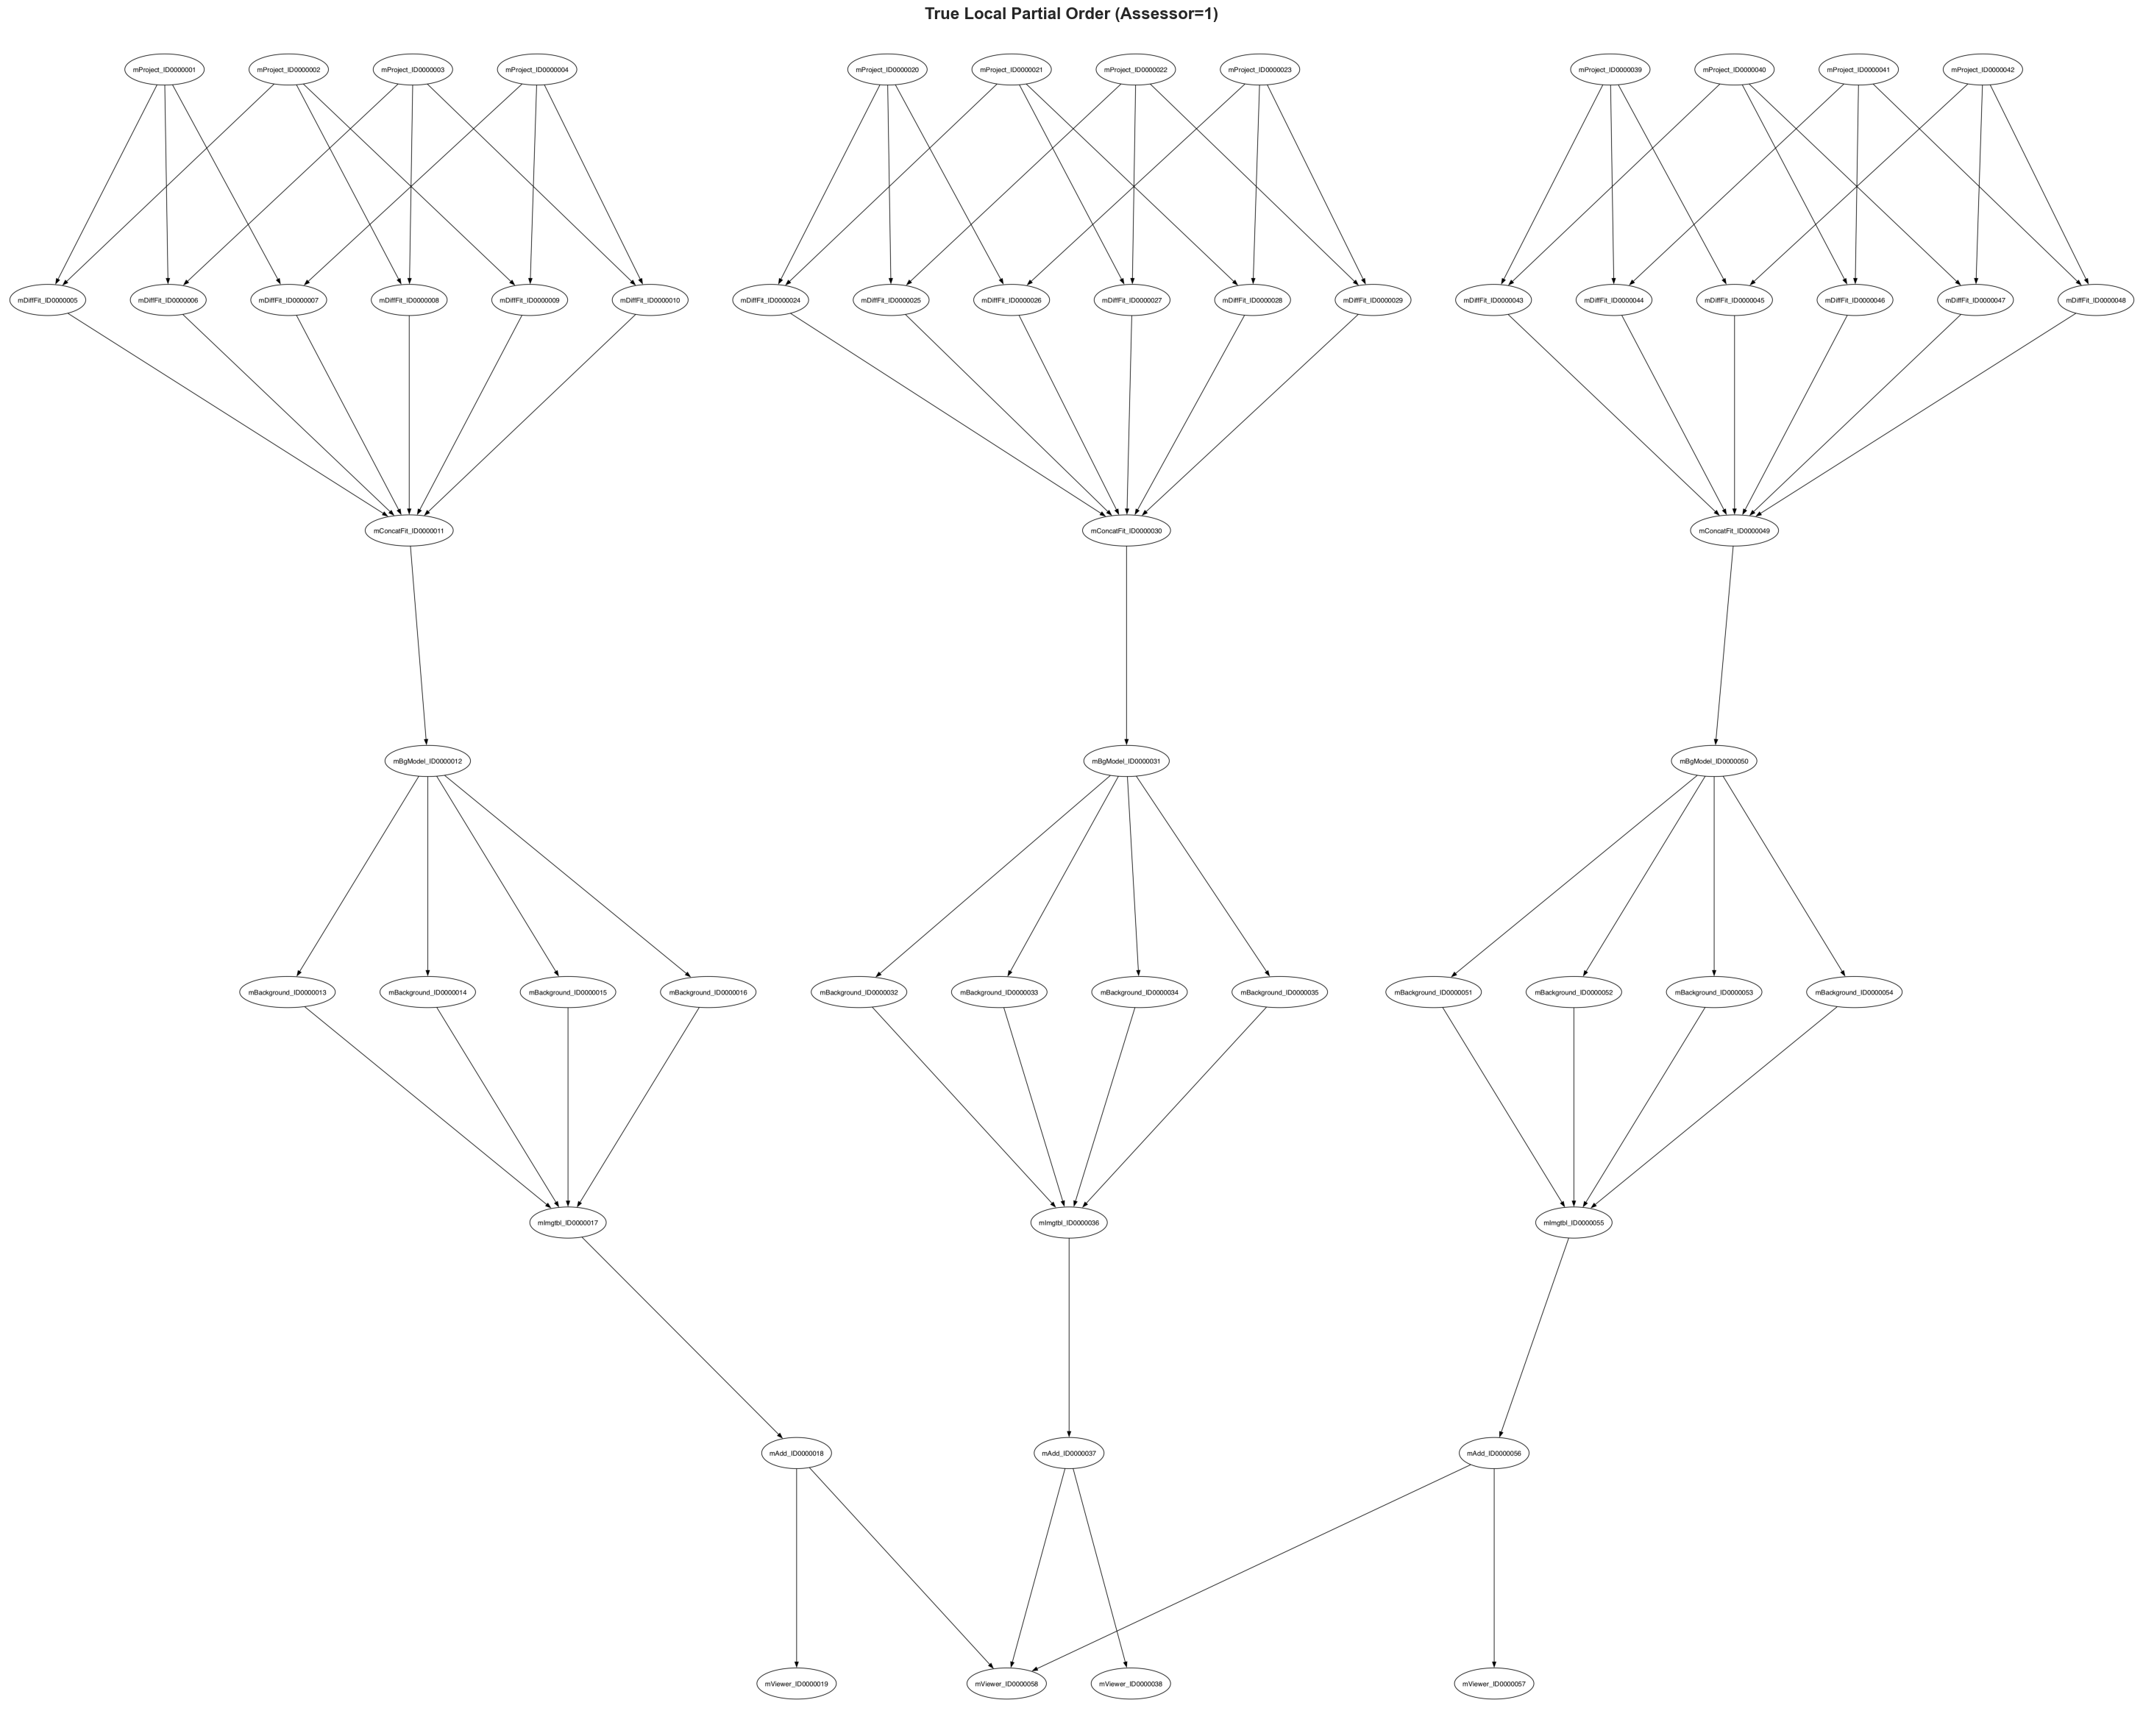

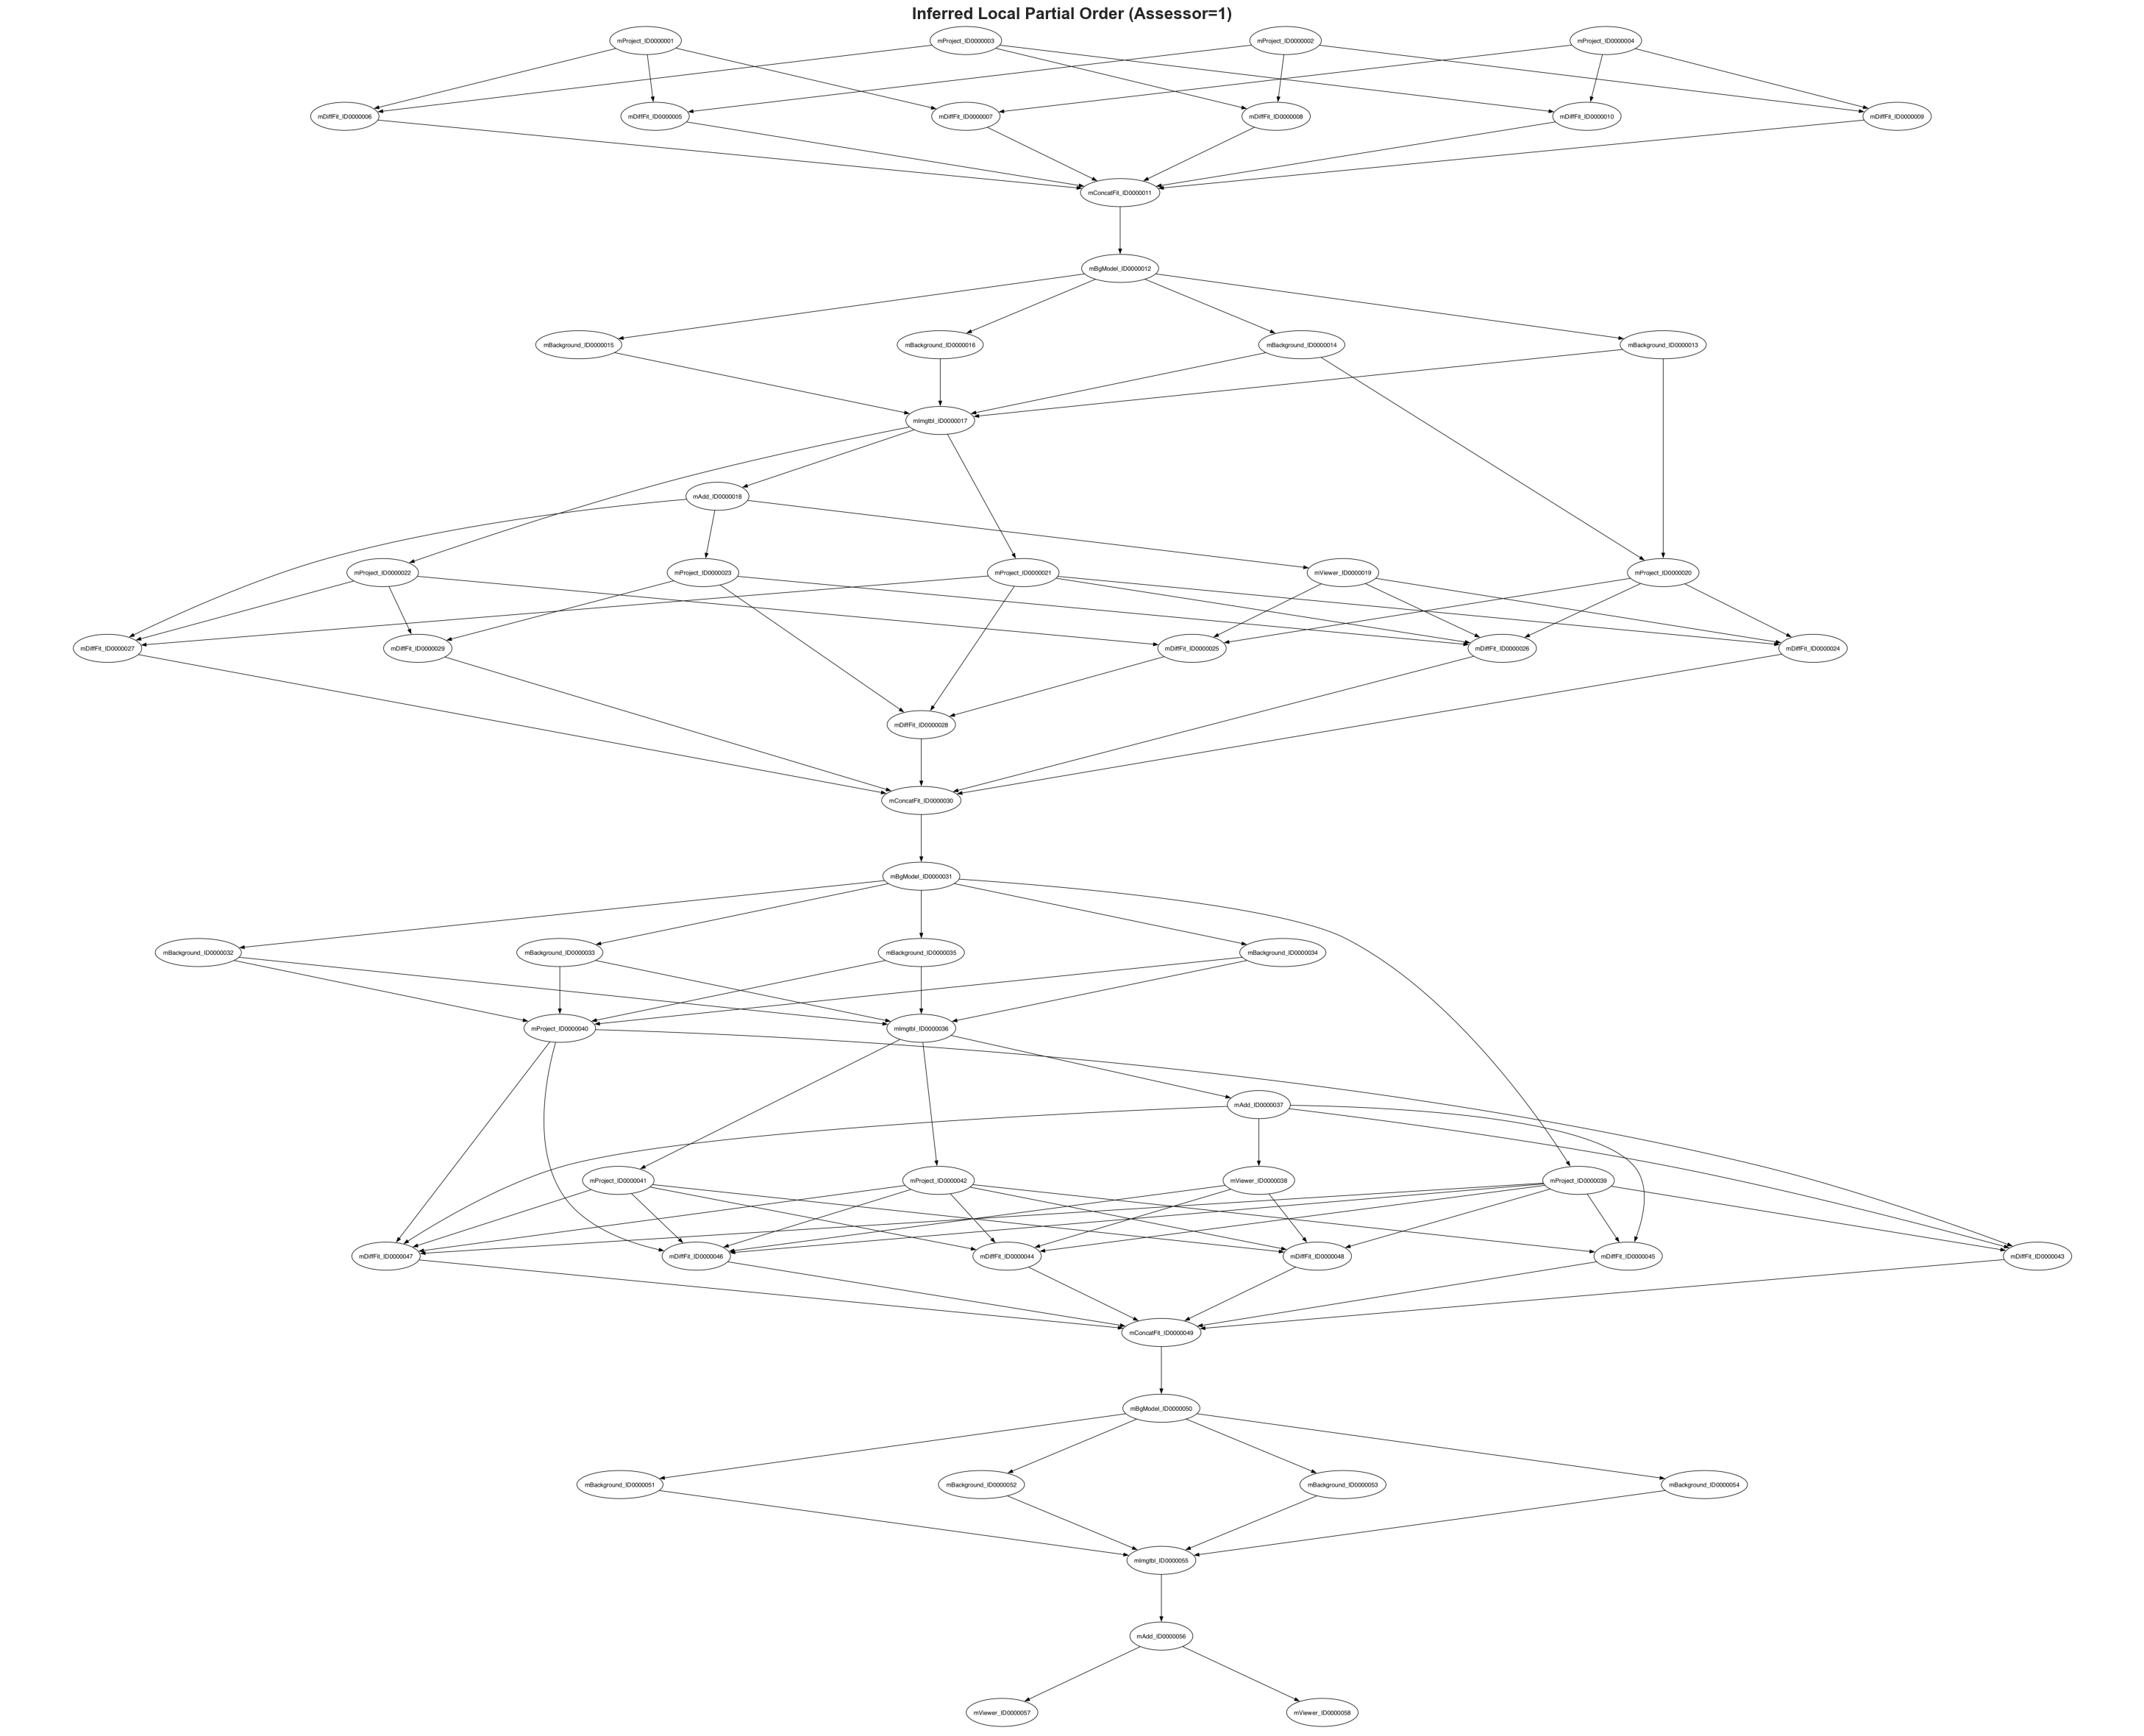


Missing edges for assessor 1:
17 < 57
24 < 29
36 < 57

Redundant edges for assessor 1:
12 < 19
13 < 19
16 < 20
16 < 21
17 < 22
17 < 26
18 < 23
18 < 24
18 < 25
20 < 25
24 < 27
30 < 38
31 < 39
32 < 39
33 < 39
34 < 39
35 < 40
35 < 41
36 < 42
36 < 44
36 < 46
37 < 43
37 < 45
37 < 47
38 < 45
38 < 46
38 < 47
40 < 46
41 < 43
41 < 45


In [41]:

# Create index_to_item_local_dict: maps assessor -> {local_index: global_item_id}
# For each assessor, M_a_dict[a] is a list where list[i] is the global item ID
# So index_to_item_local_dict[a][i] = M_a_dict[a][i]
index_to_item_local_dict = {
    a: {i: M_a_dict[a][i] for i in range(len(M_a_dict[a]))}
    for a in M_a_dict.keys()
}

# Create Ma_labels: convert global item IDs to task labels using idx_to_task
# M_a_dict[a] contains global item IDs, we need to convert them to task labels
Ma_labels_dict = {
    a: [idx_to_task[global_id] for global_id in M_a_dict[a]]
    for a in M_a_dict.keys()
}

a = assessor_id  # Use the assessor ID from inputs
PO_plot.compare_and_visualize_assessor(
    a,
    Ma_labels_dict[a],  # Use labels (task names) instead of IDs
    true_closure,
    final_H_mode[a],
    index_to_item_local_dict[a],  # Maps local index -> global item ID
    do_transitive_reduction=True,
)

# Model Evaluation
1. critical pairs that is missing 
2. whether the initial critical plan "observed_orders"  which is only 1 observation could pass current scheme; whether the 12 realisers/ inputs could be covered  
3. F1 score defintion and current precision rate 

In [27]:
def _to_idx_orders(orders, n, task_to_idx=None):
    orders_idx = []
    for o in orders:
        if not o:
            orders_idx.append([])
            continue
        # If task ids are strings, map via task_to_idx
        if task_to_idx and isinstance(o[0], str):
            mapped = [task_to_idx[t] for t in o if t in task_to_idx]
        else:
            mapped = list(o)
        orders_idx.append(mapped)
    return orders_idx

def _is_linear_extension(order_idx, closure):
    n = closure.shape[0]
    if len(order_idx) != n:
        return False
    pos = {t: i for i, t in enumerate(order_idx)}
    rows, cols = np.where(closure == 1)
    for i, j in zip(rows, cols):
        if i == j:
            continue
        if pos[i] >= pos[j]:
            return False
    return True

def critical_pairs_from_closure(closure):
    C = closure.astype(bool).copy()
    np.fill_diagonal(C, False)
    n = C.shape[0]
    Down = C.T
    Up = C
    crit = set()
    for x in range(n):
        Dx = Down[x]
        Ux = Up[x]
        for y in range(n):
            if x == y:
                continue
            if C[x, y] or C[y, x]:
                continue
            Dy = Down[y]
            Uy = Up[y]
            if np.all(Dx <= Dy) and np.all(Uy <= Ux):
                crit.add((x, y))
    return crit

def _covered_critical_pairs(orders_idx, crit_pairs):
    if not orders_idx:
        return 0, 0.0
    covered = set()
    for k, (x, y) in enumerate(crit_pairs):
        for order in orders_idx:
            if len(order) == 0:
                continue
            pos = {t: i for i, t in enumerate(order)}
            if x in pos and y in pos and pos[y] < pos[x]:
                covered.add(k)
                break
    return len(covered), len(covered) / max(1, len(crit_pairs))

def _label_pair(pair, idx_to_task=None):
    if idx_to_task:
        return (idx_to_task.get(pair[0], pair[0]), idx_to_task.get(pair[1], pair[1]))
    return pair

# --- get inferred closure ---
if isinstance(final_H_mode, dict):
    H_mode = final_H_mode[assessor_id]
else:
    H_mode = final_H_mode
H_mode_closure = BasicUtils.transitive_closure(H_mode.astype(np.int8))

# --- observed orders ---
orders_raw = observed_orders.get(assessor_id, [])
n = true_closure.shape[0]
orders_idx = _to_idx_orders(orders_raw, n, task_to_idx=globals().get("task_to_idx"))

valid_inferred = [ _is_linear_extension(o, H_mode_closure) for o in orders_idx ]
valid_true = [ _is_linear_extension(o, true_closure) for o in orders_idx ]

print(f"orders: {len(orders_idx)}")
print(f"valid vs final_H_mode: {sum(valid_inferred)}/{len(valid_inferred)}")
print(f"valid vs true_closure: {sum(valid_true)}/{len(valid_true)}")

# --- critical pairs ---
crit_true = critical_pairs_from_closure(true_closure)
crit_inf  = critical_pairs_from_closure(H_mode_closure)

missing = crit_true - crit_inf
extra   = crit_inf - crit_true

print(f"critical pairs (true): {len(crit_true)}")
print(f"critical pairs (inferred): {len(crit_inf)}")
print(f"missing critical pairs in inferred: {len(missing)}")
print(f"extra critical pairs in inferred: {len(extra)}")

covered_true, frac_true = _covered_critical_pairs(orders_idx, list(crit_true))
covered_inf, frac_inf   = _covered_critical_pairs(orders_idx, list(crit_inf))

print(f"coverage of TRUE critical pairs by observed orders: {covered_true}/{len(crit_true)} ({frac_true:.3f})")
print(f"coverage of INFERRED critical pairs by observed orders: {covered_inf}/{len(crit_inf)} ({frac_inf:.3f})")

# Show a few example pairs
idx_to_task_local = globals().get("idx_to_task", None)
if missing:
    ex = list(missing)[:10]
    print("missing examples:", [_label_pair(p, idx_to_task_local) for p in ex])
if extra:
    ex = list(extra)[:10]
    print("extra examples:", [_label_pair(p, idx_to_task_local) for p in ex])


orders: 50
valid vs final_H_mode: 31/50
valid vs true_closure: 50/50
critical pairs (true): 99
critical pairs (inferred): 180
missing critical pairs in inferred: 28
extra critical pairs in inferred: 109
coverage of TRUE critical pairs by observed orders: 99/99 (1.000)
coverage of INFERRED critical pairs by observed orders: 157/180 (0.872)
missing examples: [('mProject_ID0000040', 'mViewer_ID0000019'), ('mProject_ID0000042', 'mDiffFit_ID0000044'), ('mProject_ID0000002', 'mViewer_ID0000038'), ('mBackground_ID0000032', 'mBackground_ID0000033'), ('mProject_ID0000042', 'mViewer_ID0000019'), ('mProject_ID0000004', 'mViewer_ID0000038'), ('mProject_ID0000021', 'mViewer_ID0000057'), ('mProject_ID0000023', 'mViewer_ID0000057'), ('mViewer_ID0000038', 'mViewer_ID0000058'), ('mBackground_ID0000034', 'mBackground_ID0000033')]
extra examples: [('mProject_ID0000042', 'mProject_ID0000041'), ('mDiffFit_ID0000026', 'mDiffFit_ID0000024'), ('mDiffFit_ID0000045', 'mDiffFit_ID0000046'), ('mDiffFit_ID0000009'

## Baseline

In [38]:
import numpy as np
from src.utils.hpo_model_evaluation import precision_recall, f1_score, structural_hamming_distance
from src.utils.po_fun import BasicUtils

# Ensure true_cover is available (defined in Cell 8)
if 'true_cover' not in globals():
    if 'true_adj' in globals():
        true_closure = BasicUtils.transitive_closure(true_adj.astype(np.int8))
        true_cover = BasicUtils.transitive_reduction_optimized(true_closure.astype(np.int8))
    else:
        raise RuntimeError("true_cover or true_adj not found. Please run Cell 8 first.")

# ---- helpers ----
def _to_idx_order(order):
    # Orders are already indices (0 to n-1), so just return as list
    return list(order) if order else []

def _eval_cover(pred_cover, name):
    prec, rec = precision_recall(true_cover, pred_cover)
    f1 = f1_score(prec, rec)
    shd = structural_hamming_distance(true_cover, pred_cover)
    print(f"{name}: F1={f1:.3f}  P={prec:.3f}  R={rec:.3f}  SHD={shd}")

# Get orders for the assessor (already indices 0 to n-1)
orders = observed_orders.get(assessor_id, [])
orders_idx = [_to_idx_order(o) for o in orders if o]
n = len(M0)

if not orders_idx:
    raise RuntimeError("No observed orders to build baselines.")

print(f"Building baselines with {len(orders_idx)} orders, n={n} items")

# ---- Baseline 1: Intersection (hard precedence) ----
# i ≺ j if i before j in EVERY observed trace (where both appear)
before_all = np.ones((n, n), dtype=bool)
np.fill_diagonal(before_all, False)

for o in orders_idx:
    pos = {t: i for i, t in enumerate(o)}
    items = list(pos.keys())
    for i in items:
        for j in items:
            if i == j:
                continue
            if not (pos[i] < pos[j]):
                before_all[i, j] = False

inter_adj = before_all.astype(np.int8)
np.fill_diagonal(inter_adj, 0)
inter_cover = BasicUtils.transitive_reduction_optimized(inter_adj.astype(np.int8))

_eval_cover(inter_cover, "Intersection baseline (cover)")

# ---- Baseline 2: Majority (pairwise) + cycle-break ----
counts = np.zeros((n, n), dtype=int)
totals = np.zeros((n, n), dtype=int)

for o in orders_idx:
    pos = {t: i for i, t in enumerate(o)}
    items = list(pos.keys())
    for ii in range(len(items)):
        for jj in range(ii + 1, len(items)):
            a, b = items[ii], items[jj]
            totals[a, b] += 1
            totals[b, a] += 1
            if pos[a] < pos[b]:
                counts[a, b] += 1
            else:
                counts[b, a] += 1

p = np.zeros((n, n), dtype=float)
mask = totals > 0
p[mask] = counts[mask] / totals[mask]

# cycle-break: order by average position in traces
mean_rank = np.zeros(n, dtype=float)
rank_count = np.zeros(n, dtype=float)
for o in orders_idx:
    pos = {t: i for i, t in enumerate(o)}
    for t, i in pos.items():
        mean_rank[t] += i
        rank_count[t] += 1
mean_rank = np.divide(mean_rank, rank_count, out=np.zeros_like(mean_rank), where=rank_count > 0)
order = np.argsort(mean_rank)
rank = np.empty(n, dtype=int)
rank[order] = np.arange(n)

maj_adj = np.zeros((n, n), dtype=np.int8)
for i in range(n):
    for j in range(n):
        if i == j or totals[i, j] == 0:
            continue
        if p[i, j] > 0.5 and rank[i] < rank[j]:
            maj_adj[i, j] = 1

maj_closure = BasicUtils.transitive_closure(maj_adj.astype(np.int8))
maj_cover = BasicUtils.transitive_reduction_optimized(maj_closure)

_eval_cover(maj_cover, "Majority baseline (cover)")


Building baselines with 50 orders, n=58 items
Intersection baseline (cover): F1=1.000  P=1.000  R=1.000  SHD=0
Majority baseline (cover): F1=0.240  P=0.260  R=0.222  SHD=127


In [39]:
from src.utils.hpo_model_evaluation import precision_recall, f1_score, structural_hamming_distance
from src.utils.po_fun import BasicUtils
import numpy as np

# true cover
true_closure = BasicUtils.transitive_closure(true_adj.astype(np.int8))
true_cover = BasicUtils.transitive_reduction_optimized(true_closure)

# choose assessor
if "assessor_id" in globals():
    a = assessor_id
else:
    a = next(iter(h_trace_k[0].keys()))

item_labels = labels if "labels" in globals() else None

thresholds = [0.1 * i for i in range(1, 10)]
results = []

for thr in thresholds:
    final_H_mode = build_final_partial_orders(
        h_trace_k,
        method="threshold",
        threshold=thr,
        top_n=4,
        item_labels=item_labels,
    )
    H_mode = final_H_mode[a] if isinstance(final_H_mode, dict) else final_H_mode
    H_mode = H_mode.copy()
    np.fill_diagonal(H_mode, 0)

    shd = structural_hamming_distance(true_cover, H_mode)
    precision, recall = precision_recall(true_cover, H_mode)
    cover_f1 = f1_score(precision, recall)

    results.append(
        {
            "method": "threshold",
            "threshold": thr,
            "f1": cover_f1,
            "precision": precision,
            "recall": recall,
            "shd": shd,
        }
    )

# Posterior mode aggregation
final_H_mode = build_final_partial_orders(
    h_trace_k,
    method="mode",
    top_n=4,
    item_labels=item_labels,
)
H_mode = final_H_mode[a] if isinstance(final_H_mode, dict) else final_H_mode
H_mode = H_mode.copy()
np.fill_diagonal(H_mode, 0)

shd_mode = structural_hamming_distance(true_cover, H_mode)
precision_mode, recall_mode = precision_recall(true_cover, H_mode)
cover_f1_mode = f1_score(precision_mode, recall_mode)

results.append(
    {
        "method": "mode",
        "threshold": None,
        "f1": cover_f1_mode,
        "precision": precision_mode,
        "recall": recall_mode,
        "shd": shd_mode,
    }
)

results_sorted = sorted(results, key=lambda r: r["f1"], reverse=True)

print("results (sorted by F1):")
for r in results_sorted:
    thr = "-" if r["threshold"] is None else f"{r['threshold']:.2f}"
    print(
        f"method={r['method']:<9} thr={thr:<4}  F1={r['f1']:.3f}  P={r['precision']:.3f}  R={r['recall']:.3f}  SHD={r['shd']}"
    )

best = results_sorted[0]
best_thr = "-" if best["threshold"] is None else f"{best['threshold']:.2f}"
print(
    f"best -> method={best['method']} thr={best_thr}  F1={best['f1']:.3f}  P={best['precision']:.3f}  R={best['recall']:.3f}  SHD={best['shd']}"
)


Assessor 0: 25000 post-burn samples
  1. count=1 (0.0%)
  2. count=1 (0.0%)
  3. count=1 (0.0%)
  4. count=1 (0.0%)
Assessor 1: 25000 post-burn samples
  1. count=97 (0.4%)
  2. count=94 (0.4%)
  3. count=78 (0.3%)
  4. count=78 (0.3%)
Assessor 0: 25000 post-burn samples
  1. count=1 (0.0%)
  2. count=1 (0.0%)
  3. count=1 (0.0%)
  4. count=1 (0.0%)
Assessor 1: 25000 post-burn samples
  1. count=97 (0.4%)
  2. count=94 (0.4%)
  3. count=78 (0.3%)
  4. count=78 (0.3%)
Assessor 0: 25000 post-burn samples
  1. count=1 (0.0%)
  2. count=1 (0.0%)
  3. count=1 (0.0%)
  4. count=1 (0.0%)
Assessor 1: 25000 post-burn samples
  1. count=97 (0.4%)
  2. count=94 (0.4%)
  3. count=78 (0.3%)
  4. count=78 (0.3%)
Assessor 0: 25000 post-burn samples
  1. count=1 (0.0%)
  2. count=1 (0.0%)
  3. count=1 (0.0%)
  4. count=1 (0.0%)
Assessor 1: 25000 post-burn samples
  1. count=97 (0.4%)
  2. count=94 (0.4%)
  3. count=78 (0.3%)
  4. count=78 (0.3%)
Assessor 0: 25000 post-burn samples
  1. count=1 (0.0%)


In [ ]:
import pathlib
from pathlib import Path

# Set up paths to montage data directory
project_root = Path.cwd().parents[0]  # Adjust if needed based on your notebook location
data_dir = project_root / 'data' / 'wfcommons_wfinstances' / 'montage'

# Load montage workflow instances
from src.utils.wfcommons_loader import iter_workflow_instances

# Get all montage instances
instances = list(iter_workflow_instances(data_dir))

# Example: Load a specific instance (e.g., the smallest one for testing)
montage_instance = None
for inst in instances:
    metadata = inst.get('metadata', {})
    source_path = metadata.get('source_path', '')
    if '005d' in source_path and '2mass' in source_path:  # Smallest instance
        montage_instance = inst
        break

if montage_instance:
    print(f"Loaded montage instance: {montage_instance['metadata']['source_path']}")
    print(f"Number of tasks: {len(montage_instance.get('task_ids', []))}")
else:
    print("Could not find montage instance")

ModuleNotFoundError: No module named 'wfcommons'